
## Beat The Bookie Coursework Final Python Notebook

Jupyter notebook portion of the coursework submission for COMP0036.


### 1. Introduction

**Library Installation**

In [ ]:
!pip install constantly==15.1.0
!pip install cssselect==1.1.0
!pip install daal4py==2023.1.1
!pip install datashape==0.5.4
!pip install et-xmlfile==1.1.0
!pip install flatbuffers==24.12.23
!pip install fonttools==4.25.0
!pip install gast==0.6.0
!pip install google-pasta==0.2.0
!pip install grpcio==1.68.1
!pip install h5py==3.12.1
!pip install imbalanced-learn==0.13.0
!pip install inflection==0.5.1
!pip install keras==3.7.0
!pip install libclang==18.1.1
!pip install mkl-service==2.4.0
!pip install ml-dtypes==0.4.1
!pip install munkres==1.1.4
!pip install namex==0.0.8
!pip install numpy==1.26.4
!pip install openpyxl==3.0.10
!pip install opt_einsum==3.4.0
!pip install optree==0.13.1
!pip install patsy==0.5.3
!pip install pep8==1.7.1
!pip install ply==3.11
!pip install protobuf==5.29.2
!pip install pyaml==24.12.1
!pip install pyarrow==11.0.0
!pip install pyasn1-modules==0.2.8
!pip install pycurl==7.45.2
!pip install PyDispatcher==2.0.5
!pip install pyls-spyder==0.4.0
!pip install PyQt5==5.15.7
!pip install PyQtWebEngine==5.15.4
!pip install python-lsp-jsonrpc==1.0.0
!pip install pywin32==305.1
!pip install queuelib==1.5.0
!pip install rich==13.9.4
!pip install scikit-learn==1.5.2
!pip install scikit-learn-intelex==20230426.121932
!pip install scikit-optimize==0.10.2
!pip install scipy==1.11.1
!pip install sklearn-compat==0.1.3
!pip install sympy==1.13.1
!pip install TBB==0.2
!pip install tensorboard==2.18.0
!pip install tensorboard-data-server==0.7.2
!pip install tensorflow-io-gcs-filesystem==0.31.0
!pip install tensorflow_intel==2.18.0
!pip install termcolor==2.5.0
!pip install threadpoolctl==3.5.0
!pip install torch==2.5.1+cu124
!pip install torchaudio==2.5.1+cu124
!pip install torchvision==0.20.1+cu124
!pip install typing_extensions==4.9.0
!pip install webencodings==0.5.1
!pip install xgboost==2.1.3

In [ ]:
# @title
# Standard Library Imports
import os
import pickle

from collections import Counter, OrderedDict
import random

# Third-Party Libraries for Data Manipulation
import pandas as pd
import numpy as np


# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

# TensorFlow
import tensorflow as tf
from torch.utils.data import DataLoader, TensorDataset

# Scikit-learn Modules
from sklearn import (
    linear_model,
    tree,
    discriminant_analysis,
    naive_bayes,
    ensemble,
    gaussian_process,
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    train_test_split,
    TimeSeriesSplit,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    log_loss,
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    make_scorer,
)

# Imbalanced-Learn for Oversampling
from imblearn.over_sampling import SMOTE, RandomOverSampler

# XGBoost
import xgboost as xgb

# Hyperparameter Optimization (Bayesian Search)
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Data Import

Modify data_dir to the path of the provided "data" folder in SUBMISSION.zip
The data files (xxyy_games.csv) in the folder were scraped from online sources using Selenium.

In [ ]:
# @title
data_dir = "data"

In [ ]:
print(os.listdir(data_dir))

['1718_games.csv', '1819_games.csv', '1920_games.csv', '2021_games.csv', '2122_games.csv', '2122_players.csv', '2223_games.csv', '2223_players.csv', '2324_games.csv', '2324_players.csv', '2324_summary.csv', '2425_games.csv', '2425_players.csv', 'column_dtypes.txt', 'column_names.txt', 'data_raw', 'features_17_24_full_ema_span=30.csv', 'ranked_players.csv', 'team_elo.csv', 'transformed2.csv']


### 3. Data Transformation & Exploration



#### 3.1 Feature Extraction

##### 3.1.1 General data cleaning

Drop duplicate columns (Scraped data and given data have some overlap), NaNs and duplicate entries

In [ ]:
# @title
def drop_duplicate_columns(data: pd.DataFrame) -> pd.DataFrame:
    # checks if the data and datatype are equal and deletes the column
    cols = data.columns
    duplicate_cols = []
    for i in range(len(cols)):
        for j in range(i):
            if data[cols[i]].dtype == data[cols[j]].dtype:
                if data[cols[i]].equals(data[cols[j]]):
                    duplicate_cols.append(cols[i])
                    break
    data = data.drop(columns=duplicate_cols)
    return data

def clean_data(data: pd.DataFrame) -> pd.DataFrame:

    print("Original Length:", len(data), len(data.columns))
    data = data.dropna(how="all")
    print("After dropping NaN:", len(data), len(data.columns))
    data = data.drop_duplicates()
    print("After dropping duplicate rows:", len(data), len(data.columns))
    data = drop_duplicate_columns(data)
    print("After dropping duplicate columns:", len(data), len(data.columns))

    # An "@" in the column indicates that the team is playing away
    data["HomeGame"] = ~data["Unnamed: 13"].eq("@")
    data = data.drop(columns=["Unnamed: 13", "Match Report", "Comp", "Rk"])
    print("After dropping columns:", len(data), len(data.columns))

    data["Date"] = pd.to_datetime(data["Date"])
    data = data.drop(columns=["Result"])

    data["FTR"] = data.apply(
        lambda row: (
            "D"
            if row["GD"] == 0
            else ("H" if (not (row["GD"] > 0) ^ row["HomeGame"]) else "A")
        ),
        axis=1,
    )
    # opta_cols = [
    #     "xG",
    #     "npxG",
    #     "xGD",
    #     "npxGD",
    #     "xAG",
    #     "xA",
    #     "G-xG",
    #     "np:G-xG",
    #     "A-xAG",
    #     "npxG/Sh",
    # ]
    # data = data.drop(columns=opta_cols)
    return data.dropna().copy()

# Helper function to combine all years data files (xxyy_games.csv) into one raw_data object
def get_all_season_data(data_dir):
    data_files = filter(
        lambda x: x.endswith("_games.csv"),
        os.listdir(data_dir),
    )
    raw_data = pd.concat(
        pd.read_csv(os.path.join(data_dir, file), encoding="latin1")
        for file in data_files
    )
    return raw_data.reset_index(drop=True)

##### 3.1.2 Add Performance indicators

Create some mathematical performance indicator features sourced from the internet.

In [ ]:
def calculate_defensive_capability(df): #calculates the Defensive Capability Metric
    weights = {
        "TklW": 0.25,
        "Int": 0.25,
        "Blocks": 0.20,
        "Recov": 0.15,
        "Clr": 0.10,
        "Def 3rd": 0.05,
    }
    dcm = sum(weights[feature] * df[feature] for feature in weights)
    return (dcm - dcm.min()) / (dcm.max() - dcm.min())  # Normalized DCM


def calculate_attacking_capability(df): #calculates the Attacking Capability Metric

    weights = {"KP": 0.35, "SCA": 0.3, "GCA": 0.2, "PrgP": 0.15}
    acm = sum(weights[feature] * df[feature] for feature in weights)
    return (acm - acm.min()) / (acm.max() - acm.min())  # Normalized ACM


def calculate_possession_influence(df): #calculates the Possession Influence Metric

    weights = {"Poss": 0.3, "Cmp%": 0.25, "PrgDist": 0.2, "Carries": 0.15, "PrgC": 0.1}
    pim = sum(weights[feature] * df[feature] for feature in weights)
    return (pim - pim.min()) / (pim.max() - pim.min())  # Normalized PIM


def calculate_efficiency(df): #calculates the Efficiency Metric

    weights = {"G/Sh": 0.4, "SoT%": 0.3, "Tkl%": 0.2, "Cmp%": 0.1}
    em = sum(weights[feature] * df[feature] for feature in weights)
    return (em - em.min()) / (em.max() - em.min())  # Normalized EM


def calculate_expected_performance(df): #calculates the Expected Performance Metric

    weights = {"xG": 0.4, "xA": 0.3, "xGD": 0.2, "npxGD": 0.1}
    epm = sum(weights[feature] * df[feature] for feature in weights)
    return (epm - epm.min()) / (epm.max() - epm.min())  # Normalized EPM


def calculate_physical_intensity(df): #calculates the Physical Intensity Metric

    weights = {"Tkl": 0.45, "Int": 0.4, "TotDist": 0.15}
    pim = sum(weights[feature] * df[feature] for feature in weights)
    return (pim - pim.min()) / (pim.max() - pim.min())  # Normalized PIM


def calculate_creativity(df): # calculates the Creativity Metric

    weights = {"KP": 0.4, "SCA": 0.3, "PrgP": 0.2, "1/3": 0.1}
    cm = sum(weights[feature] * df[feature] for feature in weights)
    return (cm - cm.min()) / (cm.max() - cm.min())  # Normalized CM

def add_performance_indicators(data): #adding all metrics to the dataset
    data["DCM"] = calculate_defensive_capability(data)
    data["ACM"] = calculate_attacking_capability(data)
    data["PIM"] = calculate_possession_influence(data)
    data["EM"] = calculate_efficiency(data)
    data["EPM"] = calculate_expected_performance(data)
    data["Physical_Intensity"] = calculate_physical_intensity(data)
    data["Creativity"] = calculate_creativity(data)
    return data

##### 3.1.3 Create Exponential Moving Average (EMA) features

Given the clean raw match data, exponential moving averages are then calculated. Then we restructure the data such that each row has all of the information from that match (both home and away team features), which is a more suitable format for match outcome predictions.

In [ ]:
# @title
def create_ema_features(data: pd.DataFrame, span = 30): #creates exponential moving average (EMA) features for numerical columns in the dataset.
    df = data
    non_feature_cols = ["Date", "HomeGame", "FTR", "Team", "Opp"]
    feature_names = df.drop(columns=non_feature_cols).columns
    ema_features = []
    for feature_name in feature_names:
        feature_ema = data.groupby("Team")[feature_name].transform( #group calculations by team
            lambda row: row.ewm(span=span, min_periods=2).mean().shift(1)
        )
        ema_features.append(pd.Series(feature_ema, name="f_ema_" + feature_name))
    df = pd.concat([df, pd.concat(ema_features, axis=1)], axis=1)
    return df.dropna().reset_index(drop=True)


def restructure_data(data: pd.DataFrame): # merges the data such that each row represents features for both the home and away team in a particular match.
    unwanted_cols = ["Opp_home", "Opp_away", "HomeGame_home", "HomeGame_away"]
    data_merged = (
        data.query("HomeGame == True")
        .rename(columns={"Team": "HomeTeam"})
        .pipe(
            pd.merge,
            data.query("HomeGame == False")
            .rename(columns={"Team": "AwayTeam"})
            .drop(columns="FTR"),
            left_on=[
                "Date",
                "HomeTeam",
                "Opp",
            ],
            right_on=[
                "Date",
                "Opp",
                "AwayTeam",
            ],
            suffixes=("_home", "_away"),
        )
    )
    data_merged = data_merged.drop(columns=unwanted_cols)
    return data_merged.drop_duplicates(
    subset=["Date", "HomeTeam", "AwayTeam"]
).reset_index(drop=True)

##### 3.1.4 Create Seasonal Features

Add features for win / loss streaks and overall season data (e.g. total number of goals scored this season), etc.

In [ ]:
# @title
def add_seasonal_features(df: pd.DataFrame):
    team_stats = {}
    season_threshold = 60  # gap to detect new season

    # resets team stats at the start of a new season
    def reset_team_stats():
        return {
            "GoalsScored": 0,
            "GoalsConceded": 0,
            "Points": 0,
            "Form": ["M"] * 5,
            "WinStreak3": 0,
            "WinStreak5": 0,
            "LossStreak3": 0,
            "LossStreak5": 0,
        }

    # calculates win/loss streaks
    def update_streaks(form):
        """Calculate win/loss streaks based on the last 5 matches."""
        win_streak_3 = int(form[:3] == ["W", "W", "W"])
        win_streak_5 = int(form[:5] == ["W", "W", "W", "W", "W"])
        loss_streak_3 = int(form[:3] == ["L", "L", "L"])
        loss_streak_5 = int(form[:5] == ["L", "L", "L", "L", "L"])
        return win_streak_3, win_streak_5, loss_streak_3, loss_streak_5

    # initialize matchweek counter
    matchweek = 1
    last_date = df["Date"].iloc[0]

    df = df.sort_values(by="Date", ascending=True)
    new_features = []

    for _, row in df.iterrows():
        home_team = row["HomeTeam"]
        away_team = row["AwayTeam"]
        fthg, ftag = row["GF_home"], row["GF_away"]
        ftr = row["FTR"]
        date = row["Date"]

        # check for new season if the date gap exceeds the threshold
        if (date - last_date).days > season_threshold:
            team_stats.clear()
            matchweek = 1

        if home_team not in team_stats:
            team_stats[home_team] = reset_team_stats()
        if away_team not in team_stats:
            team_stats[away_team] = reset_team_stats()

        home = team_stats[home_team]
        away = team_stats[away_team]

        # calculate goal differences
        htgd = home["GoalsScored"] - home["GoalsConceded"]
        atgd = away["GoalsScored"] - away["GoalsConceded"]

        # calculate form points
        form_points = {"W": 3, "D": 1, "L": 0}
        ht_form_pts = sum([form_points.get(x, 0) for x in home["Form"]])
        at_form_pts = sum([form_points.get(x, 0) for x in away["Form"]])

        # update streaks
        (
            home["WinStreak3"],
            home["WinStreak5"],
            home["LossStreak3"],
            home["LossStreak5"],
        ) = update_streaks(home["Form"])
        (
            away["WinStreak3"],
            away["WinStreak5"],
            away["LossStreak3"],
            away["LossStreak5"],
        ) = update_streaks(away["Form"])

        cum_stats = {
            "HTGS": home["GoalsScored"],
            "ATGS": away["GoalsScored"],
            "HTGC": home["GoalsConceded"],
            "ATGC": away["GoalsConceded"],
            "HTP": home["Points"],
            "ATP": away["Points"],
            "MatchWeek": matchweek,
        }
        win_loss_streak_stats = {
            "HTWinStreak3": home["WinStreak3"],
            "HTWinStreak5": home["WinStreak5"],
            "HTLossStreak3": home["LossStreak3"],
            "HTLossStreak5": home["LossStreak5"],
            "ATWinStreak3": away["WinStreak3"],
            "ATWinStreak5": away["WinStreak5"],
            "ATLossStreak3": away["LossStreak3"],
            "ATLossStreak5": away["LossStreak5"],
        }
        # hm1 to atformpts
        recent_form_stats = {
            "HM1": home["Form"][0],
            "HM2": home["Form"][1],
            "HM3": home["Form"][2],
            "HM4": home["Form"][3],
            "HM5": home["Form"][4],
            "AM1": away["Form"][0],
            "AM2": away["Form"][1],
            "AM3": away["Form"][2],
            "AM4": away["Form"][3],
            "AM5": away["Form"][4],
            "HTFormPtsStr": "".join(home["Form"]),
            "ATFormPtsStr": "".join(away["Form"]),
            "HTFormPts": ht_form_pts,
            "ATFormPts": at_form_pts,
        }
        goal_point_diff_stats = {
            "HTGD": htgd,
            "ATGD": atgd,
            "DiffPts": home["Points"] - away["Points"],
            "DiffFormPts": ht_form_pts - at_form_pts,
        }

        row_stats = (
            cum_stats
            | win_loss_streak_stats
            | recent_form_stats
            | goal_point_diff_stats
        )
        row_stats = {f"f_{k}": v for k, v in row_stats.items()}
        new_features.append(row_stats)

        # update stats after match
        home["GoalsScored"] += fthg
        home["GoalsConceded"] += ftag
        away["GoalsScored"] += ftag
        away["GoalsConceded"] += fthg

        if ftr == "H":
            home["Points"] += 3
            home["Form"] = (["W"] + home["Form"])[:5]
            away["Form"] = (["L"] + away["Form"])[:5]
        elif ftr == "A":
            away["Points"] += 3
            home["Form"] = (["L"] + home["Form"])[:5]
            away["Form"] = (["W"] + away["Form"])[:5]
        else:
            home["Points"] += 1
            away["Points"] += 1
            home["Form"] = (["D"] + home["Form"])[:5]
            away["Form"] = (["D"] + away["Form"])[:5]

        matchweek += 1
        last_date = date
    new_features = pd.DataFrame(new_features, index=df.index)
    df = pd.concat([df, new_features], axis=1)
    return df.copy()

##### 3.1.5 Elo System & PI Ratings

Calculate elo for each team and pi ratings. Add these as features.

In [ ]:
# @title
def add_team_elo(df: pd.DataFrame,data_dir):
    # read data/team_elo.csv
    df_elo = pd.read_csv(os.path.join(data_dir,"team_elo.csv"))
    # add a column to df for home team elo and away team elo
    for elo_column in [col for col in df_elo.columns if col != "Team"]:
        elo_dict = df_elo.set_index("Team")[elo_column].to_dict()
        df[f"f_elo_{elo_column}_home"] = df["HomeTeam"].map(elo_dict)
        df[f"f_elo_{elo_column}_away"] = df["AwayTeam"].map(elo_dict)
    df = df.fillna(0)
    return df.copy()

def get_pi_ratings(df, params): # creates pi ratings for all teams

    teams = pd.concat([df["HomeTeam"], df["AwayTeam"]]).unique()
    keys = list(set(list(df["HomeTeam"]) + list(df["AwayTeam"])))

    pi_dictionary = {f"Home {key}": 0 for key in keys}
    pi_dictionary.update({f"Away {key}": 0 for key in keys})


    c = params[0] # rating constant
    mu1 = params[1] # home weight for rating update
    mu2 = params[2] # away weight for rating update

    home_key = "Home {}"
    away_key = "Away {}"

    df_list = df.values.tolist()

    def exp_goal_diff(c, hr, ar): # calculates expected goal difference
        if ar >= 0:
            egda = 10 ** np.abs((ar) / c) - 1
        else:
            egda = -(10 ** np.abs((ar) / c) - 1)
        if hr >= 0:
            egdh = 10 ** np.abs((hr) / c) - 1
        else:
            egdh = -(10 ** np.abs((hr) / c) - 1)
        return egdh - egda

    def get_error(obs_goals, exp_goals): #calculates absolute error
        return np.abs(obs_goals - exp_goals)

    def get_weighted_error(c, error, obs_goals, exp_goals): # calculates weighted error using the parameters
        if exp_goals < obs_goals:
            we1 = c * np.log10((1 + error))
            we2 = -(we1)
        else:
            we1 = -(c * np.log10((1 + error)))
            we2 = -(we1)
        return we1, we2

    def update_ratings(wehome, weaway, hrhome, hraway, arhome, araway, mu1, mu2):
        hrhome_new = hrhome + (wehome * mu1)
        hraway_new = hrhome + (hrhome_new - hrhome) * mu2
        araway_new = araway + (weaway * mu1)
        arhome_new = arhome + (araway_new - araway) * mu2
        return hrhome_new, hraway_new, arhome_new, araway_new

    results = []

    for _, row in df.iterrows():
        home = row["HomeTeam"]
        away = row["AwayTeam"]
        date = row["Date"]
        home_score = row["GF_home"]
        away_score = row["GF_away"]

        h_hr = pi_dictionary[home_key.format(home)]
        h_ar = pi_dictionary[away_key.format(home)]
        a_hr = pi_dictionary[home_key.format(away)]
        a_ar = pi_dictionary[away_key.format(away)]

        egd = exp_goal_diff(c, h_hr, a_ar)
        obs_goals = home_score - away_score
        error = get_error(obs_goals, egd)
        wehome, weaway = get_weighted_error(c, error, obs_goals, egd)

        h_hr_new, h_ar_new, a_hr_new, a_ar_new = update_ratings(
            wehome, weaway, h_hr, h_ar, a_hr, a_ar, mu1, mu2
        )

        pi_dictionary[home_key.format(home)] = h_hr_new
        pi_dictionary[away_key.format(home)] = h_ar_new
        pi_dictionary[home_key.format(away)] = a_hr_new
        pi_dictionary[away_key.format(away)] = a_ar_new

        results.append(
            {
                "Date": date,
                "HomeTeam": home,
                "AwayTeam": away,
                "HomeGoals": home_score,
                "AwayGoals": away_score,
                "f_pi_Home Rating_home": h_hr,
                "f_pi_Away Rating_home": h_ar,
                "f_pi_Home Rating_away": a_hr,
                "f_pi_Away Rating_away": a_ar,
                "f_pi_Exp GD Pi": egd,
                "f_pi_Pi Diff": h_hr - a_ar,
            }
        )

    return pd.DataFrame(results)

def add_pi_rating(df: pd.DataFrame):
    pi_params = [1, 0.1, 0.3]
    df_ratings = get_pi_ratings(df, pi_params)
    df = pd.merge(
        df,
        df_ratings,
        on=["Date", "HomeTeam", "AwayTeam"],
    )
    return df.copy()

##### Clean and Transform the Dataset

In [ ]:
# @title
raw_data = get_all_season_data(data_dir)

# helper function which goes through the pipeline described from 3.1.1 to 3.1.5
def transform_raw_data(raw_data):
  data_cleaned = clean_data(raw_data).dropna()
  print("Data cleaned shape:", data_cleaned.shape)
  df_indicators = add_performance_indicators(data_cleaned)
  print("Data added performance indicators shape:", df_indicators.shape)
  df_ema_features = create_ema_features(df_indicators, 30)
  print("Data ema features shape:", df_ema_features.shape)
  df_restructured = restructure_data(df_ema_features)
  print("Data restructured shape:", df_restructured.shape)
  df_features = add_seasonal_features(df_restructured)
  print("Data shape after adding seasonal features:", df_features.shape)
  df_features = add_team_elo(df_features,data_dir).dropna(how="all")
  print("Data shape after adding team elo:", df_features.shape)
  df_features = add_pi_rating(df_features).dropna(how="all")
  print("Data shape after adding pi rating:", df_features.shape)
  return df_features.sort_values(by="Date", ascending=True).reset_index(drop=True)

df_features = transform_raw_data(raw_data)
data = df_features


Original Length: 5696 132
After dropping NaN: 5696 132
After dropping duplicate rows: 5696 132
After dropping duplicate columns: 5696 111
After dropping columns: 5696 108
Data cleaned shape: (5482, 108)
Data added performance indicators shape: (5482, 115)
Data ema features shape: (5420, 225)
Data restructured shape: (2590, 444)
Data shape after adding seasonal features: (2590, 477)
Data shape after adding team elo: (2590, 487)
Data shape after adding pi rating: (2590, 495)





The columns of our completed dataset can be seen below.

In [ ]:
print(data.columns)

Index(['HomeTeam', 'Date', 'xG_home', 'Cmp_home', 'TklW_home', 'Subs_home',
       'Recov_home', 'Live_home', 'GCA_home', 'TotDist_home',
       ...
       'f_elo_Weighted Elo_home', 'f_elo_Weighted Elo_away', 'HomeGoals',
       'AwayGoals', 'f_pi_Home Rating_home', 'f_pi_Away Rating_home',
       'f_pi_Home Rating_away', 'f_pi_Away Rating_away', 'f_pi_Exp GD Pi',
       'f_pi_Pi Diff'],
      dtype='object', length=495)


The data ranges from the 2017 EPL Season to the 2024 Season.

In [ ]:
# @title
print(data['Date'].min())
print(data['Date'].max())

2017-08-26 00:00:00
2024-12-30 00:00:00


#### 3.2 Feature Selection

##### 3.2.1 Correlation Analysis

Using the winning columns we can calculate the correlation between each column and the corresponding team winning their match.

In [ ]:
# @title
numeric_data = df_features.select_dtypes(include=['number'])
numeric_data = numeric_data[[col for col in numeric_data.columns if col.startswith("f_")]]
# numeric_data = numeric_data.drop(columns=numeric_data.filter(regex="^f_ema_").columns)
correlations = numeric_data.apply(lambda col: col.corr(df_features['FTR'].str.startswith('H').astype(int))).sort_values(ascending=False)

print(correlations[:20])

f_pi_Exp GD Pi           0.347825
f_pi_Pi Diff             0.343150
f_ema_EPM_home           0.290142
f_ema_npxGD_home         0.283656
f_ema_xGD_home           0.283539
f_ema_xA_home            0.279820
f_ema_npxG_home          0.275544
f_ema_xG_home            0.274727
f_DiffPts                0.271047
f_ema_GD_home            0.270678
f_ema_ACM_home           0.269670
f_ema_Creativity_home    0.268396
f_ema_GF_home            0.266292
f_ema_G-PK_home          0.264902
f_ema_GCA_home           0.264822
f_ema_xAG_home           0.263717
f_ema_PassLive.1_home    0.261563
f_ema_SoT_home           0.261081
f_ema_PPA_home           0.260736
f_ema_PassLive_home      0.260310
dtype: float64


We can get our first idea of which features might be the most useful to our models by looking at the most correlated and inversely correlated columns to the (Home) team winning a match.

(257, 1)


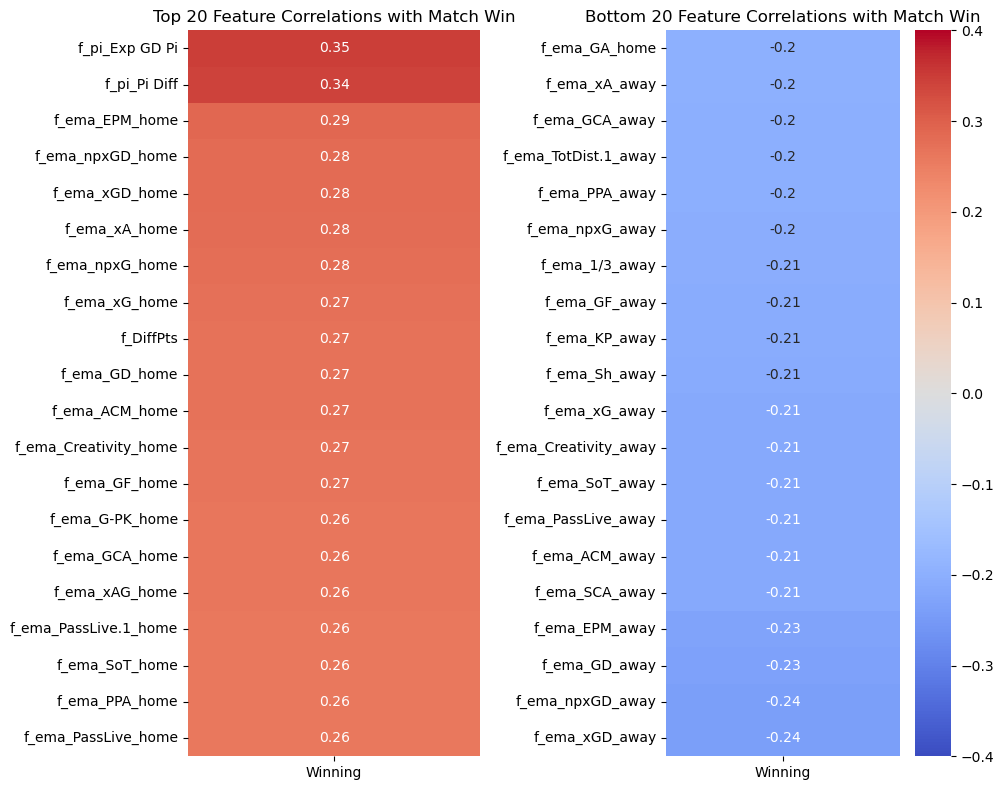

In [ ]:
# @title
correlation_df = correlations.to_frame(name='Winning')
n_features = 20
fig, axes = plt.subplots(1, 2, figsize=(10, 8))

print(correlation_df.shape)

sns.heatmap(correlation_df.head(n_features), annot=True, cmap='coolwarm', cbar =False, vmin=-0.4, vmax=0.4, ax=axes[0])
axes[0].set_title(f"Top {n_features} Feature Correlations with Match Win")

sns.heatmap(correlation_df.tail(n_features), annot=True, cmap='coolwarm', vmin=-0.4, vmax=0.4, ax=axes[1])
axes[1].set_title(f"Bottom {n_features} Feature Correlations with Match Win")

plt.tight_layout()
plt.show()

##### 3.2.2: Removing highly correlated features

First, let's visualize the correlation between the most salient features.

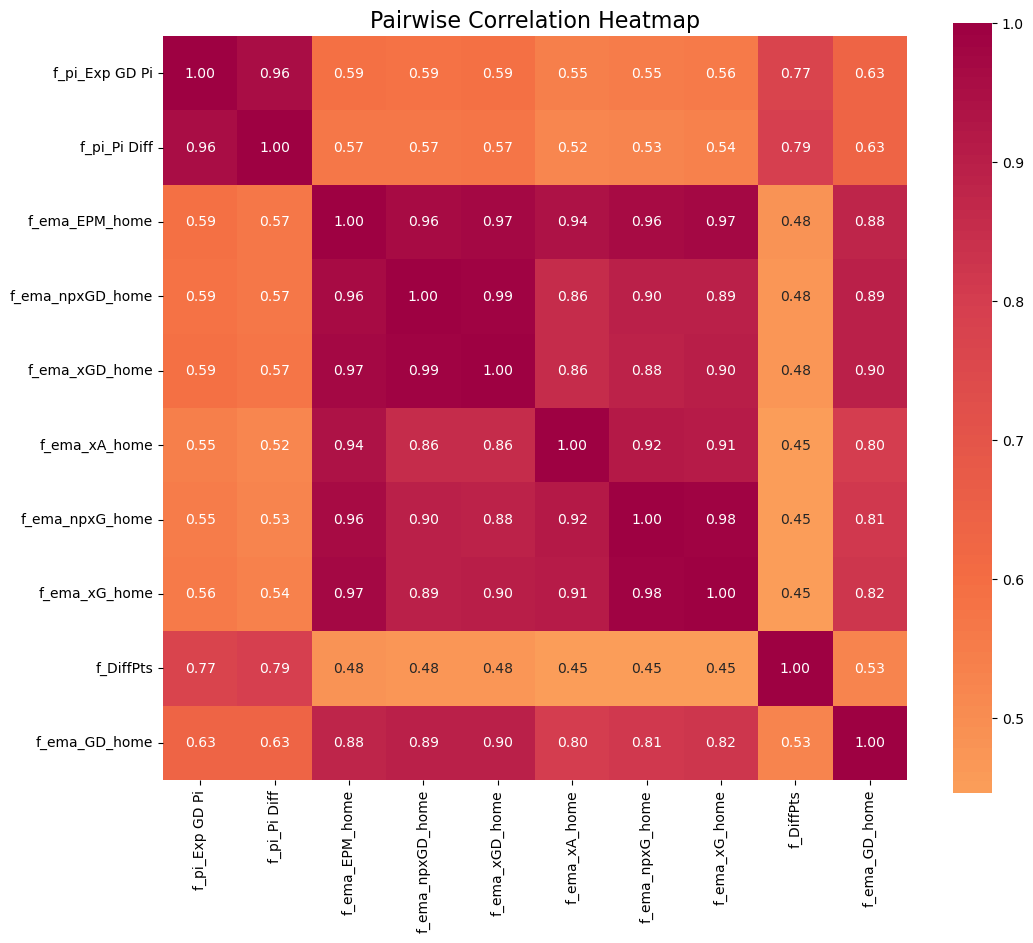

In [ ]:
n_features = 10
top_features = correlations.index[:n_features]
top_features_negative = correlations.index[-n_features:]
# features_of_interest = list(top_features)+list(top_features_negative)
features_of_interest = list(top_features)
pairwise_correlations = numeric_data[features_of_interest].corr()

diverging_palette = sns.diverging_palette(250, 10, as_cmap=True)
plt.figure(figsize=(12, 10))  # Set the figure size
sns.heatmap(
    pairwise_correlations,
    annot=True,
    fmt=".2f",
    cmap="Spectral_r",
    center = 0,
    cbar=True,
    square=True,
    vmax=1,
)

# Add a title
plt.title("Pairwise Correlation Heatmap", fontsize=16)

# Display the heatmap
plt.show()

We can see that the pairwise correlation between some of the features is extremely high. To avoid multi-collinearity, we should remove the less important feature for each pair of features with high correlation.

In [ ]:
# @title
rf_selector = RandomForestClassifier(random_state=100)
rf_selector.fit(StandardScaler().fit_transform(numeric_data), df_features["FTR"])
importances = rf_selector.feature_importances_
threshold = 0.9 # correlation threshold for removing features
print("Number of features before removal:",numeric_data.shape[1])
pairwise_correlations = numeric_data.corr()
sorted_pairwise = pairwise_correlations.unstack().sort_values(ascending=False)
sorted_pairwise_similar = sorted_pairwise[(sorted_pairwise > threshold) & (sorted_pairwise!=1.0)]

similar_feature_pairs = sorted_pairwise_similar.index  # get the pairs of similar features
features_to_remove = set()

for col1, col2 in similar_feature_pairs:
    # compare feature importances and remove the one with lower importance to the removal set
    if importances[numeric_data.columns.get_loc(col1)] < importances[numeric_data.columns.get_loc(col2)]:
        features_to_remove.add(col1)
    else:
        features_to_remove.add(col2)

numeric_data_new = numeric_data.drop(columns=features_to_remove)
correlations_cleaned = numeric_data_new.apply(lambda col: col.corr(df_features['FTR'].str.startswith('H').astype(int))).sort_values(ascending=False)
print("Number of features after removal:",numeric_data_new.shape[1])

Number of features before removal: 257
Number of features after removal: 160


#### 3.3. Data Preprocessing

##### 3.3.1 Encoding and dropping intermediate columns

In [ ]:
# @title
# encode the target variable
data = df_features.copy()
data["FTR"] = data["FTR"].astype("category")
print(data.shape)

# drop unecessary winstreak columns
object_columns = [
    "f_HM1",
    "f_HM2",
    "f_HM3",
    "f_HM4",
    "f_HM5",
    "f_AM1",
    "f_AM2",
    "f_AM3",
    "f_AM4",
    "f_AM5",
    "f_HTFormPtsStr",
    "f_ATFormPtsStr",]

data = data.drop(columns = object_columns)
data = data.drop(columns = features_to_remove)

label_encoder = LabelEncoder()
data["FTR"] = label_encoder.fit_transform(data["FTR"])
# prepare features
X = data[[col for col in data.columns if col.startswith("f_")]]
data["year"] = data["Date"].dt.year
y = data["FTR"]

(2590, 495)


##### 3.3.2 Scale & Impute

In [ ]:
# @title

# impute
imputer = SimpleImputer(strategy="mean")
X = imputer.fit_transform(X)

# scale
scaler = StandardScaler()
X = scaler.fit_transform(X)

##### 3.3.3 Misc

In [ ]:
# @title
# create the cumulative list for all matches (used in linear regression)
cumulative_list = [
    (X[data["year"] >= year], data.loc[data["year"] >= year, "FTR"], year)
    for year in range(2024, 2016, -1)
]

y_linear_home = data["HomeGoals"]
y_linear_away = data["AwayGoals"]

#### 3.4 Data Splitting

In [ ]:
# @title
# Split the data into training and testing sets
# split 80-20 first 80% for training, 20% for testing
X_train, X_test = X[: int(0.8 * len(X))], X[int(0.8 * len(X)) :]
y_train, y_test = y[: int(0.8 * len(y))], y[int(0.8 * len(y)) :]
y_linear_home_train, y_linear_home_test = y_linear_home[: int(0.8 * len(y_linear_home))], y_linear_home[int(0.8 * len(y_linear_home)) :]
y_linear_away_train, y_linear_away_test = y_linear_away[: int(0.8 * len(y_linear_away))], y_linear_away[int(0.8 * len(y_linear_away)) :]

In [ ]:
# Uncomment below code to enable Oversampling (worse performance)

# # oversampler = RandomOverSampler(random_state=100)
# oversampler = SMOTE(k_neighbors=5,random_state=100)
# X_train, y_train = oversampler.fit_resample(X_train, y_train)

#### 3.5 Final Dataset Overview



In [ ]:
# @title
print("X_train:", X_train.shape)
print("Y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("Y_test:", y_test.shape)
print(Counter(label_encoder.inverse_transform(y_train)))
print(Counter(label_encoder.inverse_transform(y_test)))

X_train: (2072, 160)
Y_train: (2072,)
X_test: (518, 160)
Y_test: (518,)
Counter({'H': 922, 'A': 680, 'D': 470})
Counter({'H': 228, 'A': 165, 'D': 125})


### 4. Methodology Overview

This section gives an overview of the model architectures used.



#### 4.1 Baseline model

##### Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

home_model = LinearRegression()
away_model = LinearRegression()

#### 4.2 SVM

In [ ]:
# placeholder. If we have no code in this section, should just write one or two sentences explaining why (maybe say it is in training section, would be better to have a model definition here though)

#### 4.3 Ensemble Learning (Random Forest, XGBoost)

Define the ensemble models of interest and their hyperparameters' search spaces (for tuning):

In [ ]:
# @title
classifier_dict = {
    "RandomForestClassifier": {
        "model": lambda: ensemble.RandomForestClassifier(random_state=1000,n_estimators = 100),
        "search_space": {
            "max_depth": Integer(3, 20),
            "min_samples_split": Integer(2, 10),
            "min_samples_leaf": Integer(1, 5),
        },
    },
    "XGBClassifier": {
        "model": lambda: xgb.XGBClassifier(
            random_state=999,
            enable_categorical=True,
            objective="multi:softmax",
            n_estimators= 100,

        ),
        "search_space": {
            "max_depth": Integer(2, 6),
            "subsample": Real(0.5, 1.0),
            "colsample_bytree": Real(0.5,1.0),
            "eta": Real(0.01, 0.3, prior="log-uniform"),
        },
    },
}

#### 4.4 ElasticNets Regression

In [ ]:
# @title
# based on: https://computingonline.net/computing/article/view/1695/895
class DeepElasticNetMLP(nn.Module):
    def __init__(self, input_shape, classes, l1_lambda=0.002, l2_lambda=0.0005):
        super(DeepElasticNetMLP, self).__init__()
        self.l1_lambda = l1_lambda
        self.l2_lambda = l2_lambda

        self.fc1 = nn.Linear(input_shape, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, classes)

        self.leaky_relu = nn.LeakyReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.leaky_relu(self.fc1(x))
        x = self.leaky_relu(self.fc2(x))
        x = self.leaky_relu(self.fc3(x))
        x = self.softmax(self.fc4(x))
        return x

    def elastic_net_loss(self, outputs, targets, criterion):
        # Compute standard cross-entropy loss
        loss = criterion(outputs, targets)

        # Add L1 regularization
        l1_reg = sum(torch.sum(torch.abs(param)) for param in self.parameters())

        # Add L2 regularization
        l2_reg = sum(torch.sum(torch.square(param)) for param in self.parameters())

        # Combine cross-entropy loss with Elastic Net regularization
        total_loss = loss + self.l1_lambda * l1_reg + self.l2_lambda * l2_reg
        return total_loss


#### 4.5 GRU

In [ ]:
# @title
class GRU(nn.Module):
    def __init__(self, input_size, num_classes):
        super(GRU, self).__init__()

        self.gru1 = nn.GRU(
            input_size=input_size,
            hidden_size=32,
            batch_first=True,
            dropout=0.3
        )
        self.dropout1 = nn.Dropout(0.3)

        self.gru2 = nn.GRU(
            input_size=32,
            hidden_size=16,
            batch_first=True,
            dropout=0.2,
        )
        self.dropout2 = nn.Dropout(0.3)

        self.fc = nn.Linear(16, num_classes)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        gru_out, _ = self.gru1(x)
        gru_out = self.dropout1(gru_out)

        gru_out, _ = self.gru2(gru_out)
        gru_out = self.dropout2(gru_out[:, -1, :])

        out = self.softmax(self.fc(gru_out))
        return out


#### 4.6 Neural Network Integration (GRU + MLP)

##### Base MLP

In [ ]:
# @title
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_size, output_size)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return self.softmax(x)

##### Hybrid GRU & MLP

In [ ]:
# @title
class HybridGRUMLP(nn.Module):
    def __init__(self, seq_features, n_features, num_classes):
        super(HybridGRUMLP, self).__init__()

        # GRU Branch
        self.gru1 = nn.GRU(
            input_size=seq_features,
            hidden_size=32,
            batch_first=True,
        )
        self.gru2 = nn.GRU(
            input_size=32,
            hidden_size=64,
            batch_first=True,
        )
        self.mlp = nn.Sequential(
            nn.Linear(n_features, 32),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(16, 4),
            nn.ReLU(),
            nn.Dropout(0.1)
        )

        self.dropout1 = nn.Dropout(0.5)
        self.dropout2 = nn.Dropout(0.4)
        self.dropout_gru_final = nn.Dropout(0.2)

        self.final = nn.Linear(68, num_classes)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, gru_input, mlp_input):
        gru_out, _ = self.gru1(gru_input)
        gru_out = self.dropout1(gru_out)
        gru_out, _ = self.gru2(gru_out)
        gru_out = self.dropout2(gru_out[:, -1, :])
        gru_out = self.dropout_gru_final(gru_out)

        mlp_out = self.mlp(mlp_input)

        combined = torch.cat((gru_out, mlp_out), dim=1)

        out = self.softmax(self.final(combined))

        return out

#### 4.7 Meta Stacking Model

In [ ]:
# SKlearn adaptor for the models to be included in the meta model
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.base import BaseEstimator, ClassifierMixin

import torch
import torch.nn.functional as F

class SklearnCompatibleGRUMLP(BaseEstimator, ClassifierMixin):
    def __init__(self, num_epochs=10, batch_size=32, learning_rate=0.0003, device=None):
        self.num_epochs = num_epochs
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.device = device if device else ("cuda" if torch.cuda.is_available() else "cpu")


    def fit(self, X, y):
        seed = 50
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed) if torch.cuda.is_available() else None
        np.random.seed(seed)
        random.seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        model = HybridGRUMLP(seq_features=X_train.shape[1],
                            n_features=X_train.shape[1],
                            num_classes=3)
        self.model = HybridGRUMLP(seq_features=X.shape[1],
                              n_features=X.shape[1],
                              num_classes=len(set(y)))
        self.model.to(self.device)
        X_gru = X.reshape((X.shape[0], 1, X.shape[1]))
        X_mlp = X

        X_gru = torch.FloatTensor(X_gru).to(self.device)
        X_mlp = torch.FloatTensor(X_mlp).to(self.device)
        y_train = torch.LongTensor(y.values if isinstance(y, pd.Series) else y).to(self.device)

        train_dataset = TensorDataset(X_gru, X_mlp, y_train)
        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=False)

        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate)

        for epoch in range(self.num_epochs):
            self.model.train()
            total_loss = 0
            all_preds = []
            all_labels = []

            for batch_gru, batch_mlp, batch_y in train_loader:
                batch_gru = batch_gru.to(self.device)
                batch_mlp = batch_mlp.to(self.device)
                batch_y = batch_y.to(self.device)

                optimizer.zero_grad()
                outputs = self.model(batch_gru, batch_mlp)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()

                total_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(batch_y.cpu().numpy())

            train_loss = total_loss / len(train_loader)
            train_acc = accuracy_score(all_labels, all_preds)
            if (epoch + 1) % (self.num_epochs//5) == 0:
              print(f'Epoch {epoch+1}/{self.num_epochs}, Loss: {train_loss:.4f}, Acc: {train_acc:.4f}')

        self.classes_ = torch.unique(y_train).cpu().numpy()
        return self

    def predict(self, X):
        X_gru = X.reshape((X.shape[0], 1, X.shape[1]))
        X_mlp = X

        # Move tensors to the correct device
        X_gru = torch.FloatTensor(X_gru).to(self.device)
        X_mlp = torch.FloatTensor(X_mlp).to(self.device)

        self.model.eval()
        with torch.no_grad():
            predictions_prob = self.model(X_gru, X_mlp)
            predictions = torch.argmax(predictions_prob, dim=1)

        return predictions.cpu().numpy()

    def predict_proba(self, X):
        X_gru = X.reshape((X.shape[0], 1, X.shape[1]))
        X_mlp = X

        # Move tensors to the correct device
        X_gru = torch.FloatTensor(X_gru).to(self.device)
        X_mlp = torch.FloatTensor(X_mlp).to(self.device)

        self.model.eval()
        with torch.no_grad():
            outputs = self.model(X_gru, X_mlp)
            probs = F.softmax(outputs, dim=1).cpu().numpy()
        return probs


class SklearnCompatibleElasticNetMLP(BaseEstimator, ClassifierMixin):
    def __init__(self, num_epochs=50, batch_size=32, learning_rate=0.001):
        self.num_epochs = num_epochs
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


    def fit(self, X, y):
        seed = 90
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed) if torch.cuda.is_available() else None
        np.random.seed(seed)
        random.seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        self.model = DeepElasticNetMLP(X.shape[1], len(set(y)))
        self.model.to(self.device)
        X = torch.FloatTensor(X).to(self.device)
        y = torch.LongTensor(y.values if isinstance(y, pd.Series) else y).to(self.device)

        dataset = TensorDataset(X, y)
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=False)

        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate)

        for epoch in range(self.num_epochs):
            self.model.train()
            total_loss = 0
            for batch_X, batch_y in loader:
                optimizer.zero_grad()
                outputs = self.model(batch_X)
                loss = self.model.elastic_net_loss(outputs, batch_y, criterion)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()

            if (epoch + 1) % 20 == 0:
                print(f'Epoch {epoch+1}/{self.num_epochs}, Loss: {total_loss/len(loader):.4f}')

        self.classes_ = np.unique(y.cpu().numpy())
        return self

    def predict(self, X):
        X = torch.FloatTensor(X).to(self.device)
        self.model.eval()
        with torch.no_grad():
            predictions = self.model(X).argmax(dim=1)
        return predictions.cpu().numpy()

    def predict_proba(self, X):
        X = torch.FloatTensor(X).to(self.device)
        self.model.eval()
        with torch.no_grad():
            probs = F.softmax(self.model(X), dim=1)
        return probs.cpu().numpy()

### 5. Model Training & Validation

#### Baseline Model

##### Linear Regression

In [ ]:
# Perform Linear regression on the Expected Goals and then manually classify based on the difference in goals
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report
import numpy as np

def predict_match_outcomes(X_train, X_test):
    home_model = LinearRegression()
    away_model = LinearRegression()

    home_model.fit(X_train, y_linear_home_train)
    away_model.fit(X_train, y_linear_away_train)

    home_xg = home_model.predict(X_test)
    away_xg = away_model.predict(X_test)

    def get_result(home_xg, away_xg):
        if home_xg > away_xg:
            return 'H'
        elif away_xg > home_xg:
            return 'A'
        else:
            return 'D'

    predicted_ftr = [get_result(h, a) for h, a in zip(home_xg, away_xg)]

    label_encoder = LabelEncoder()
    label_encoder.fit(['A', 'D', 'H'])
    encoded_predictions = label_encoder.transform(predicted_ftr)

    return encoded_predictions, home_xg, away_xg


print(len(X_train),len(X_test),len(y_linear_home_train),len(y_linear_away_train))
linear_predictions, home_xg, away_xg = predict_match_outcomes(X_train, X_test)
accuracy = accuracy_score(y_test, linear_predictions)
print(f"Accuracy: {accuracy}")
print(f"F1 Score: {f1_score(y_test, linear_predictions, average='weighted')}")
print("\nClassification Report:")
print(classification_report(y_test, linear_predictions))
linear_conf_matrix = confusion_matrix(y_test, linear_predictions)
print(linear_conf_matrix)

2072 518 2072 2072
Accuracy: 0.48841698841698844
F1 Score: 0.4237766033965457

Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.65      0.51       165
           1       0.00      0.00      0.00       125
           2       0.55      0.64      0.59       228

    accuracy                           0.49       518
   macro avg       0.32      0.43      0.37       518
weighted avg       0.38      0.49      0.42       518

[[107   0  58]
 [ 64   0  61]
 [ 82   0 146]]


C:\Users\super\anaconda3\envs\COMP0036\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\super\anaconda3\envs\COMP0036\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\super\anaconda3\envs\COMP0036\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)

#### MLP

In [ ]:
epochs = 50
tscv = TimeSeriesSplit(n_splits=10)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test.values if isinstance(y_test, pd.Series) else y_test, dtype=torch.long)

# Cross-Validation Loop
mlp_fold_accuracy = []
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
    X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
    y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

    model = MLP(X_train_fold.shape[1], 64, len(label_encoder.classes_))
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_fold)
        loss = criterion(outputs, y_train_fold)
        loss.backward()
        optimizer.step()
    model.eval()
    with torch.no_grad():
        val_predictions = model(X_val_fold).argmax(axis=1)
        val_loss = criterion(model(X_val_fold), y_val_fold)
        val_accuracy = accuracy_score(y_val_fold,val_predictions)
    mlp_fold_accuracy.append(val_accuracy)
    print(f"Fold {fold + 1}, Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")


# Train the model on the full train set
print("\nTraining MLP on full train set:")
mlp_model = MLP(X_train.shape[1], 64, len(label_encoder.classes_))
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=0.001)
loss_history = []
for epoch in range(epochs):
    mlp_model.train()
    optimizer.zero_grad()
    outputs = mlp_model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}")

Fold 1, Validation Loss: 1.0146, Validation Accuracy: 0.5000
Fold 2, Validation Loss: 0.9776, Validation Accuracy: 0.5585
Fold 3, Validation Loss: 1.0170, Validation Accuracy: 0.4787
Fold 4, Validation Loss: 1.0323, Validation Accuracy: 0.4681
Fold 5, Validation Loss: 1.0539, Validation Accuracy: 0.4574
Fold 6, Validation Loss: 1.0423, Validation Accuracy: 0.4681
Fold 7, Validation Loss: 0.9927, Validation Accuracy: 0.5479
Fold 8, Validation Loss: 0.9709, Validation Accuracy: 0.5745
Fold 9, Validation Loss: 1.0063, Validation Accuracy: 0.5213
Fold 10, Validation Loss: 0.9755, Validation Accuracy: 0.5585

Training MLP on full train set:
Epoch 10/50, Loss: 1.0445
Epoch 20/50, Loss: 0.9916
Epoch 30/50, Loss: 0.9772
Epoch 40/50, Loss: 0.9667
Epoch 50/50, Loss: 0.9543


In [ ]:
# @title
# Evaluate the model
print("MLP Mean Validation Accuracy:", np.mean(mlp_fold_accuracy))
mlp_model.eval()
with torch.no_grad():
    mlp_predictions = mlp_model(X_test).argmax(axis=1)

MLP Mean Validation Accuracy: 0.5132978723404256


#### Elastic Net

In [ ]:
epochs = 50
tscv = TimeSeriesSplit(n_splits=10)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test.values if isinstance(y_test, pd.Series) else y_test, dtype=torch.long)

# Cross-Validation Loop
elasticnet_fold_accuracy = []
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):

    X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
    y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]
    model = DeepElasticNetMLP(X_train.shape[1], len(label_encoder.classes_))
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_fold)
        loss = criterion(outputs, y_train_fold)
        loss.backward()
        optimizer.step()
    model.eval()
    with torch.no_grad():
        val_predictions = model(X_val_fold).argmax(axis=1)
        val_loss = criterion(model(X_val_fold), y_val_fold)
        val_accuracy = accuracy_score(y_val_fold,val_predictions)
    elasticnet_fold_accuracy.append(val_accuracy)
    print(f"Fold {fold + 1}, Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

# Train the model on the full train set
print("\nTraining ElasticNet on full train set:")
elasticnet_model = DeepElasticNetMLP(X_train.shape[1], len(label_encoder.classes_))
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(elasticnet_model.parameters(), lr=0.001)
elasticnet_loss_history = []
for epoch in range(epochs):
    elasticnet_model.train()
    optimizer.zero_grad()
    outputs = elasticnet_model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    elasticnet_loss_history.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}")

Fold 1, Validation Loss: 1.0231, Validation Accuracy: 0.5000


C:\Users\super\AppData\Local\Temp\ipykernel_15592\1486404070.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train, dtype=torch.float32)
C:\Users\super\AppData\Local\Temp\ipykernel_15592\1486404070.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype=torch.long)
C:\Users\super\AppData\Local\Temp\ipykernel_15592\1486404070.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(X_test, dtype=torch.float32)
C:\Users\super\AppData\Local\Temp\ipykernel_15592\1

Fold 2, Validation Loss: 0.9880, Validation Accuracy: 0.5479
Fold 3, Validation Loss: 1.0228, Validation Accuracy: 0.4894
Fold 4, Validation Loss: 1.0396, Validation Accuracy: 0.4521
Fold 5, Validation Loss: 1.0664, Validation Accuracy: 0.4309
Fold 6, Validation Loss: 1.0534, Validation Accuracy: 0.4787
Fold 7, Validation Loss: 1.0076, Validation Accuracy: 0.5372
Fold 8, Validation Loss: 0.9749, Validation Accuracy: 0.5585
Fold 9, Validation Loss: 1.0086, Validation Accuracy: 0.5213
Fold 10, Validation Loss: 0.9740, Validation Accuracy: 0.5798

Training ElasticNet on full train set:
Epoch 10/50, Loss: 1.0546
Epoch 20/50, Loss: 0.9969
Epoch 30/50, Loss: 0.9769
Epoch 40/50, Loss: 0.9638
Epoch 50/50, Loss: 0.9480


In [ ]:
# Report validation results & Get predictions on test set
print("ElasticNet Mean Validation Accuracy:", np.mean(elasticnet_fold_accuracy))
elasticnet_model.eval()
with torch.no_grad():
    elastic_net_predictions = elasticnet_model(X_test).argmax(axis=1)

ElasticNet Mean Validation Accuracy: 0.5095744680851063


#### SVM

In [ ]:
# @title
X_train = X_train.cpu().numpy() if torch.is_tensor(X_train) else np.array(X_train)
X_test = X_test.cpu().numpy() if torch.is_tensor(X_test) else np.array(X_test)
y_train = y_train.cpu().numpy() if torch.is_tensor(y_train) else np.array(y_train)
y_test = y_test.cpu().numpy() if torch.is_tensor(y_test) else np.array(y_test)

#using a random forest to select the feature for the SVM
params = OrderedDict([('max_depth', 10), ('min_samples_leaf', 3), ('min_samples_split', 5), ('n_estimators', 100)])
rf_selector = RandomForestClassifier(**params)

rf_selector.fit(X_train, y_train)
importances = rf_selector.feature_importances_
indices = np.argsort(importances)[::-1]

n_features_to_select = 10
selected_features_idx = indices[:n_features_to_select].copy()
X_train_selected = X_train[:, selected_features_idx]
X_test_selected = X_test[:, selected_features_idx]

param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto'],
}

# Hyperparameter tuning with cross validation
svm_grid = GridSearchCV(SVC(), param_grid_svm, cv=TimeSeriesSplit(n_splits=5), verbose=2)
svm_grid.fit(X_train_selected, y_train)

print("Best SVM Parameters:", svm_grid.best_params_)
print("Best SVM Weighted F1 Score:", svm_grid.best_score_)

svm_model = SVC(
    **svm_grid.best_params_,
    probability=True
)

svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.1s
[CV] END ...................C=0.1, gamma=auto, kernel=linear; total time=   0.0s
[CV] END ...................C=0.1, gamma=auto, k

#### GRU

In [ ]:
# @title
import random
def train_gru_model(model, X_train, y_train, num_classes, epochs=50):
    # converting data to tensor for pytorch model
    X_train = torch.FloatTensor(X_train.reshape((X_train.shape[0], 1, X_train.shape[1])))
    y_train = torch.LongTensor(y_train.values if isinstance(y_train, pd.Series) else y_train)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # training
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        outputs = model(X_train)
        loss = criterion(outputs, y_train)

        loss.backward()
        optimizer.step()

        # evaluation
        model.eval()
        with torch.no_grad():
            train_predicted = torch.argmax(outputs, dim=1)
            train_acc = accuracy_score(y_train.cpu(), train_predicted.cpu())
            train_f1 = f1_score(y_train.cpu(), train_predicted.cpu(), average='weighted')

    return model, train_acc, train_f1, train_predicted

def predict_gru_model(model, X_test): # getting predictions
    X_test = torch.FloatTensor(X_test.reshape((X_test.shape[0], 1, X_test.shape[1])))

    model.eval()
    with torch.no_grad():
        predictions_prob = model(X_test)
        predictions = torch.argmax(predictions_prob, dim=1)

    return predictions.numpy()

# # Usage
# model = GRU(input_size=X_train.shape[1], num_classes=3)
# history = train_gru_model(model, X_train, y_train, num_classes=3)
# gru_predictions = predict_gru_model(model, X_test)
# gru_val_acc = accuracy_score(y_test, gru_predictions)
# gru_val_f1 = f1_score(y_test, gru_predictions, average='weighted')
# print(f'Test Accuracy : {gru_val_acc}')
# print(f'Test F1 Score : {gru_val_f1}')
# print(classification_report(y_test, gru_predictions))
# fig, axes = plt.subplots(1, 1, figsize=(15, 6))
# gru_conf_matrix = confusion_matrix(y_test, gru_predictions)
# sns.heatmap(gru_conf_matrix, annot=True, fmt="d", cmap="Blues",
#             xticklabels=label_encoder.classes_,
#             yticklabels=label_encoder.classes_, ax=axes)
# axes.set_xlabel("Predicted")
# axes.set_ylabel("Actual")
# axes.set_title("GRU Confusion Matrix Heatmap")

# plt.tight_layout()
# plt.show()

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

def cross_validate_gru_time_series(model, X_train, y_train, num_classes, k=10, epochs=20): # cross validation for gru model
    fold_train = []
    fold_results = []
    tscv = TimeSeriesSplit(n_splits=k)

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
        print(f"Fold {fold + 1}/{k}")

        X_train_fold, y_train_fold = X_train[train_idx], y_train[train_idx]
        X_val_fold, y_val_fold = X_train[val_idx], y_train[val_idx]

        model = model = GRU(input_size=X_train.shape[1], num_classes=3)

        # training model on fold and updating it
        model, train_acc, train_f1, train_predicted = train_gru_model(
            model, X_train_fold, y_train_fold, num_classes=num_classes, epochs=epochs
        )
        fold_train.append((train_acc, train_f1))

        print("Train Accuracy :", train_acc)
        print("Train F1 Score :", train_f1)
        predictions = predict_gru_model(model, X_val_fold)
        val_acc = accuracy_score(y_val_fold, predictions)
        print('Validation Accuracy :', val_acc)
        f1_val = f1_score(y_val_fold, predictions, average='weighted')
        print('Validation F1 Score :', f1_val)
        fold_results.append((val_acc, f1_val))

    print("\n Final Results (Averaged)")
    avg_train_acc =  np.mean([x[0] for x in fold_train])
    avg_train_f1 = np.mean([x[1] for x in fold_train])
    avg_val_acc = np.mean([x[0] for x in fold_results])
    avg_val_f1 = np.mean([x[1] for x in fold_results])
    print('\nAverage Training Accuracy :', avg_train_acc)
    print('Average Training F1 Score :', avg_train_f1)
    print('\nAverage Validation Accuracy :', avg_val_acc)
    print('Average Validation F1 Score :', avg_val_f1)
    # returning model trained on fold
    return avg_train_acc, avg_train_f1, avg_val_acc, avg_val_f1

model = GRU(input_size=X_train.shape[1], num_classes=3)

gru_train_acc, gru_train_f1, gru_val_acc, gru_val_f1 = cross_validate_gru_time_series(
    model, X_train, y_train, num_classes=3, k=10, epochs=50
)

model = GRU(input_size=X_train.shape[1], num_classes=3)

# re-training model on entire dataset
train_gru_model(model, X_train, y_train, num_classes=3, epochs=50)

gru_predictions = predict_gru_model(model, X_test)

Fold 1/10


C:\Users\super\anaconda3\envs\COMP0036\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(
C:\Users\super\anaconda3\envs\COMP0036\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


Train Accuracy : 0.671875
Train F1 Score : 0.6468731608492915
Validation Accuracy : 0.5159574468085106
Validation F1 Score : 0.48614685318556966
Fold 2/10


C:\Users\super\anaconda3\envs\COMP0036\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(
C:\Users\super\anaconda3\envs\COMP0036\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


Train Accuracy : 0.5815789473684211
Train F1 Score : 0.5072546574350445
Validation Accuracy : 0.5478723404255319
Validation F1 Score : 0.49022069512356287
Fold 3/10


...

C:\Users\super\anaconda3\envs\COMP0036\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(
C:\Users\super\anaconda3\envs\COMP0036\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


Train Accuracy : 0.5524764150943396
Train F1 Score : 0.4821484582889083
Validation Accuracy : 0.5372340425531915
Validation F1 Score : 0.4713142602385931
Fold 10/10


C:\Users\super\anaconda3\envs\COMP0036\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(
C:\Users\super\anaconda3\envs\COMP0036\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


Train Accuracy : 0.5520169851380042
Train F1 Score : 0.48503046511471426
Validation Accuracy : 0.5425531914893617
Validation F1 Score : 0.4880173018470891

 Final Results (Averaged)

Average Training Accuracy : 0.572323795930187
Average Training F1 Score : 0.5053316644198474

Average Validation Accuracy : 0.523936170212766
Average Validation F1 Score : 0.465621415485202


C:\Users\super\anaconda3\envs\COMP0036\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(
C:\Users\super\anaconda3\envs\COMP0036\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


#### GRU + MLP

In [105]:
# @title
def train_hybrid_model(model, X_train, y_train, num_classes, epochs=50):
    # preparing data for both gru and mlp
    X_gru = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
    X_mlp = X_train

    # converting to tensor for pytorch
    X_gru = torch.FloatTensor(X_gru)
    X_mlp = torch.FloatTensor(X_mlp)
    y_train = torch.LongTensor(y_train.values if isinstance(y_train, pd.Series) else y_train)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)

    # training
    for epoch in range(epochs):
        model.train()
        total_loss = 0

        optimizer.zero_grad()
        outputs = model(X_gru, X_mlp)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)

        train_loss = total_loss / len(X_train)

        if epoch % 10 == 0:
          train_acc = accuracy_score(y_train.cpu(), predicted.cpu())
          train_f1 = f1_score(y_train.cpu(), predicted.cpu(), average='weighted')

    train_pred_np = predicted.cpu().numpy()

    # returning trained model
    return model, train_acc, train_f1, train_pred_np

def predict_hybrid_model(model, X_test): # getting predictions
    X_gru = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))
    X_mlp = X_test

    X_gru = torch.FloatTensor(X_gru)
    X_mlp = torch.FloatTensor(X_mlp)

    model.eval()
    with torch.no_grad():
        predictions_prob = model(X_gru, X_mlp)
        predictions = torch.argmax(predictions_prob, dim=1)

    return predictions.numpy()


# model = HybridGRUMLP(seq_features=X_train.shape[1],
#                     n_features=X_train.shape[1],
#                     num_classes=3)

# history = train_hybrid_model(model, X_train, y_train, 3)

# gru_mlp_predictions = predict_hybrid_model(model, X_test)
# print(f'Test Accuracy : {accuracy_score(y_test, gru_mlp_predictions)}')
# print(f'Test F1 Score : {f1_score(y_test, gru_mlp_predictions, average="weighted")}')
# print(classification_report(y_test, gru_mlp_predictions))
# fig, axes = plt.subplots(1, 1, figsize=(9, 6))
# gru_mlp_conf_matrix = confusion_matrix(y_test, gru_mlp_predictions)

# sns.heatmap(gru_mlp_conf_matrix, annot=True, fmt="d", cmap="Blues",
#             xticklabels=label_encoder.classes_,
#             yticklabels=label_encoder.classes_, ax=axes)
# axes.set_xlabel("Predicted")
# axes.set_ylabel("Actual")
# axes.set_title("GRU MLP Confusion Matrix Heatmap")

# plt.tight_layout()
# plt.show()

In [112]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

def cross_validate_gru_mlp_time_series(X_train, y_train, num_classes, k=10, epochs=50):
    fold_results = []
    fold_train = []
    tscv = TimeSeriesSplit(n_splits=k)

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
        print(f"\nFold {fold + 1}/{k}")

        X_train_fold, y_train_fold = X_train[train_idx], y_train[train_idx]
        X_val_fold, y_val_fold = X_train[val_idx], y_train[val_idx]

        model = HybridGRUMLP(n_features=X_train.shape[1], seq_features = X_train.shape[1], num_classes=3)
        # training model on fold and updating it
        model, train_acc, train_f1, train_pred_np = train_hybrid_model(
            model, X_train_fold, y_train_fold, num_classes=num_classes, epochs=epochs
        )

        print("Train Accuracy :", train_acc)
        print("Train F1 Score :", train_f1)
        fold_train.append((train_acc, train_f1))
        # predicting on validation set
        val_predictions = predict_hybrid_model(model, X_val_fold)
        val_acc = accuracy_score(y_val_fold, val_predictions)
        print('\nValidation Accuracy :', val_acc)
        f1_val = f1_score(y_val_fold, val_predictions, average='weighted')
        print('Validation F1 Score :', f1_val)
        fold_results.append((val_acc, f1_val))

    print("\n Final Results (Averaged)")
    avg_train_acc =  np.mean([x[0] for x in fold_train])
    avg_train_f1 = np.mean([x[1] for x in fold_train])
    avg_val_acc = np.mean([x[0] for x in fold_results])
    avg_val_f1 = np.mean([x[1] for x in fold_results])
    print('\nAverage Training Accuracy :', avg_train_acc)
    print('Average Training F1 Score :', avg_train_f1)
    print('\nAverage Validation Accuracy :', avg_val_acc)
    print('Average Validation F1 Score :', avg_val_f1)
    # returning model trained on fold
    return avg_train_acc, avg_train_f1, avg_val_acc, avg_val_f1

gru_mlp_train_acc, gru_mlp_train_f1, gru_mlp_val_acc, gru_mlp_val_f1= cross_validate_gru_mlp_time_series(
    X_train, y_train, num_classes=3, k=10, epochs=50
)
model = HybridGRUMLP(n_features=X_train.shape[1], seq_features = X_train.shape[1], num_classes=3)
# re-training model on entire dataset
train_hybrid_model(model, X_train, y_train, num_classes=3, epochs=50)

gru_mlp_predictions = predict_hybrid_model(model, X_test)



Fold 1/10
Train Accuracy : 0.4895833333333333
Train F1 Score : 0.45326502612724734

Validation Accuracy : 0.4627659574468085
Validation F1 Score : 0.36515917684273064

Fold 2/10
Train Accuracy : 0.4868421052631579
Train F1 Score : 0.4034889737046267

Validation Accuracy : 0.5372340425531915
Validation F1 Score : 0.45824468085106385

Fold 3/10
Train Accuracy : 0.5105633802816901
Train F1 Score : 0.4203707400997171

Validation Accuracy : 0.5372340425531915
Validation F1 Score : 0.4550550777123887

Fold 4/10
Train Accuracy : 0.5092592592592593
Train F1 Score : 0.4216464703605034

Validation Accuracy : 0.5106382978723404
Validation F1 Score : 0.4275561843608859

Fold 5/10
Train Accuracy : 0.5254237288135594
Train F1 Score : 0.4573834340649184

Validation Accuracy : 0.4946808510638298
Validation F1 Score : 0.42708355833963346

Fold 6/10
Train Accuracy : 0.48939929328621906
Train F1 Score : 0.46530607674121655

Validation Accuracy : 0.4787234042553192
Validation F1 Score : 0.438461538461538

#### Ensemble Methods (RandomForest, XGBoost)

In [ ]:
# Hyperparameter tuning using Bayes Optimization
def get_tuned_params(
    model,search_space, X_train, y_train, n_iter = 30,cv_splits=10, scoring=None
):
      print("Tuning",str(model))
      search = BayesSearchCV(
          model,
          search_spaces=search_space,
          cv=TimeSeriesSplit(cv_splits),
          scoring=scoring,
          n_iter=n_iter,
          n_jobs=-1,
          verbose=1,
          refit=False
      )
      search.fit(X_train, y_train)
      return search.best_params_

Tune the ensemble models' hyperparameters with Bayes Optimization:

In [ ]:
for model_name in classifier_dict:
    model_info = classifier_dict[model_name]
    base_model = model_info["model"]()
    search_space = model_info["search_space"]
    tuned_params = get_tuned_params(
        base_model, search_space, X_train, y_train, n_iter=30, scoring=None
    )
    model_info["tuned_params"] = tuned_params

Tuning RandomForestClassifier(random_state=1000)
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candi

Report the models' validation accuracy and obtain their predictions on the test set:

In [ ]:
# Initialize models with tuned hyperparameters
xgb_params = classifier_dict["XGBClassifier"]["tuned_params"]
rf_params = classifier_dict["RandomForestClassifier"]["tuned_params"]
xgb_model = xgb.XGBClassifier(random_state=100,**xgb_params)
rf_model = ensemble.RandomForestClassifier(random_state=100,**rf_params)

# Get the models' validation accuracy
xgb_val_scores = cross_val_score(xgb_model, X_train, y_train,cv=TimeSeriesSplit(10))
rf_val_scores = cross_val_score(rf_model, X_train, y_train,cv=TimeSeriesSplit(10))
print("XGBoost Validation Accuracy:", np.mean(xgb_val_scores), "stdev =",np.std(xgb_val_scores))
print("RandomForest Validation Accuracy:", np.mean(rf_val_scores),"stdev =",np.std(rf_val_scores))

# Test set predictions
xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_test)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

XGBoost Validation Accuracy: 0.5297872340425531 stdev = 0.029730188537196004
RandomForest Validation Accuracy: 0.5244680851063829 stdev = 0.03747641479533731


### Ensemble Stacking Model

#### Train ensemble models and fit stacking model



In [ ]:
from sklearn.model_selection import cross_val_predict

def get_stacking_model_predictions(X_train,y_train,X_test):
    n_classes = len(set(y_train))
    # Initialize the base models
    svm = SVC(**svm_grid.best_params_, probability=True, random_state = 100)
    rf = RandomForestClassifier(**rf_params, random_state = 100)
    xgb_model = xgb.XGBClassifier(objective="multi:softmax", **xgb_params, random_state=100)
    grumlp = SklearnCompatibleGRUMLP(num_epochs=10)
    elasticnet = SklearnCompatibleElasticNetMLP(num_epochs=50)

    tscv = TimeSeriesSplit(n_splits=10)
    meta_features_train = []
    base_models = [grumlp, elasticnet, svm, rf, xgb_model]
    # Obtain the predictions of the base models on the train set (using cross-validation)
    for i,base_model in enumerate(base_models):
        meta_train = np.zeros((X_train.shape[0], n_classes))
        # Generate out-of-fold predictions
        for idx, (train_idx, test_idx) in enumerate(tscv.split(X_train)):
            X_train_fold, X_test_fold = X_train[train_idx], X_train[test_idx]
            y_train_fold, y_test_fold = y_train[train_idx], y_train[test_idx]
            base_model.fit(X_train_fold, y_train_fold)
            predictions = base_model.predict_proba(X_test_fold)
            meta_train[test_idx] = predictions

        meta_features_train.append(meta_train)

    # Stack predictions into meta-features for training the meta-model
    X_train_meta = np.hstack(meta_features_train)

    # Train the meta-model on meta-features
    meta_model = LogisticRegression(random_state=100, max_iter=1500)
    meta_model.fit(X_train_meta, y_train)

    # Retrain base models on the entire train set
    grumlp = SklearnCompatibleGRUMLP(num_epochs = 10)
    elasticnet = SklearnCompatibleElasticNetMLP(num_epochs=50)
    base_models = [grumlp, elasticnet, svm, rf, xgb_model]
    meta_features_test = []
    for i,base_model in enumerate(base_models):
        base_model.fit(X_train, y_train)
        meta_test = base_model.predict_proba(X_test)
        meta_features_test.append(meta_test)

    # Get test set predictions using the base models' test predictions
    X_test_meta = np.hstack(meta_features_test)
    predictions = meta_model.predict(X_test_meta)
    return predictions

meta_predictions = get_stacking_model_predictions(X_train,y_train,X_test)

Epoch 2/10, Loss: 1.1008, Acc: 0.3021
Epoch 4/10, Loss: 1.0950, Acc: 0.3438
Epoch 6/10, Loss: 1.0907, Acc: 0.4375
Epoch 8/10, Loss: 1.0886, Acc: 0.4635
Epoch 10/10, Loss: 1.0861, Acc: 0.4688
Epoch 2/10, Loss: 1.1004, Acc: 0.3000
Epoch 4/10, Loss: 1.0918, Acc: 0.4211
Epoch 6/10, Loss: 1.0862, Acc: 0.4079
Epoch 8/10, Loss: 1.0765, Acc: 0.4947
Epoch 10/10, Loss: 1.0556, Acc: 0.5184
Epoch 2/10, Loss: 1.0957, Acc: 0.3662
Epoch 4/10, Loss: 1.0865, Acc: 0.4525
Epoch 6/10, Loss: 1.0686, Acc: 0.5123
Epoch 8/10, Loss: 1.0473, Acc: 0.5194
Epoch 10/10, Loss: 1.0263, Acc: 0.5299
Epoch 2/10, Loss: 1.0969, Acc: 0.3254
Epoch 4/10, Loss: 1.0800, Acc: 0.4934
Epoch 6/10, Loss: 1.0543, Acc: 0.5238
Epoch 8/10, Loss: 1.0251, Acc: 0.5503
Epoch 10/10, Loss: 1.0063, Acc: 0.5648
Epoch 2/10, Loss: 1.0955, Acc: 0.3602
Epoch 4/10, Loss: 1.0754, Acc: 0.4831
Epoch 6/10, Loss: 1.0507, Acc: 0.5222
Epoch 8/10, Loss: 1.0179, Acc: 0.5403
Epoch 10/10, Loss: 1.0041, Acc: 0.5477
Epoch 2/10, Loss: 1.0944, Acc: 0.3807
Epoch 4

#### Validate the Stacked Model's Performance on subsets of train set

Epoch 2/12, Loss: 1.1083, Acc: 0.3824
Epoch 4/12, Loss: 1.1012, Acc: 0.3235
Epoch 6/12, Loss: 1.1023, Acc: 0.3235
Epoch 8/12, Loss: 1.1056, Acc: 0.2941
Epoch 10/12, Loss: 1.0924, Acc: 0.4706
Epoch 12/12, Loss: 1.0935, Acc: 0.3235
Epoch 2/12, Loss: 1.1004, Acc: 0.3220
Epoch 4/12, Loss: 1.1014, Acc: 0.2712
Epoch 6/12, Loss: 1.0998, Acc: 0.3220
Epoch 8/12, Loss: 1.0991, Acc: 0.2542
Epoch 10/12, Loss: 1.0897, Acc: 0.4576
Epoch 12/12, Loss: 1.0935, Acc: 0.4068
Epoch 2/12, Loss: 1.1052, Acc: 0.2381
Epoch 4/12, Loss: 1.0978, Acc: 0.3452
Epoch 6/12, Loss: 1.0987, Acc: 0.3214
Epoch 8/12, Loss: 1.0937, Acc: 0.3214
Epoch 10/12, Loss: 1.0933, Acc: 0.4167
Epoch 12/12, Loss: 1.0921, Acc: 0.4405
Epoch 2/12, Loss: 1.1002, Acc: 0.3670
Epoch 4/12, Loss: 1.1011, Acc: 0.3028
Epoch 6/12, Loss: 1.0949, Acc: 0.3761
Epoch 8/12, Loss: 1.0915, Acc: 0.3761
Epoch 10/12, Loss: 1.0836, Acc: 0.5321
Epoch 12/12, Loss: 1.0866, Acc: 0.4771
Epoch 2/12, Loss: 1.1054, Acc: 0.2537
Epoch 4/12, Loss: 1.1004, Acc: 0.3358
Epoc

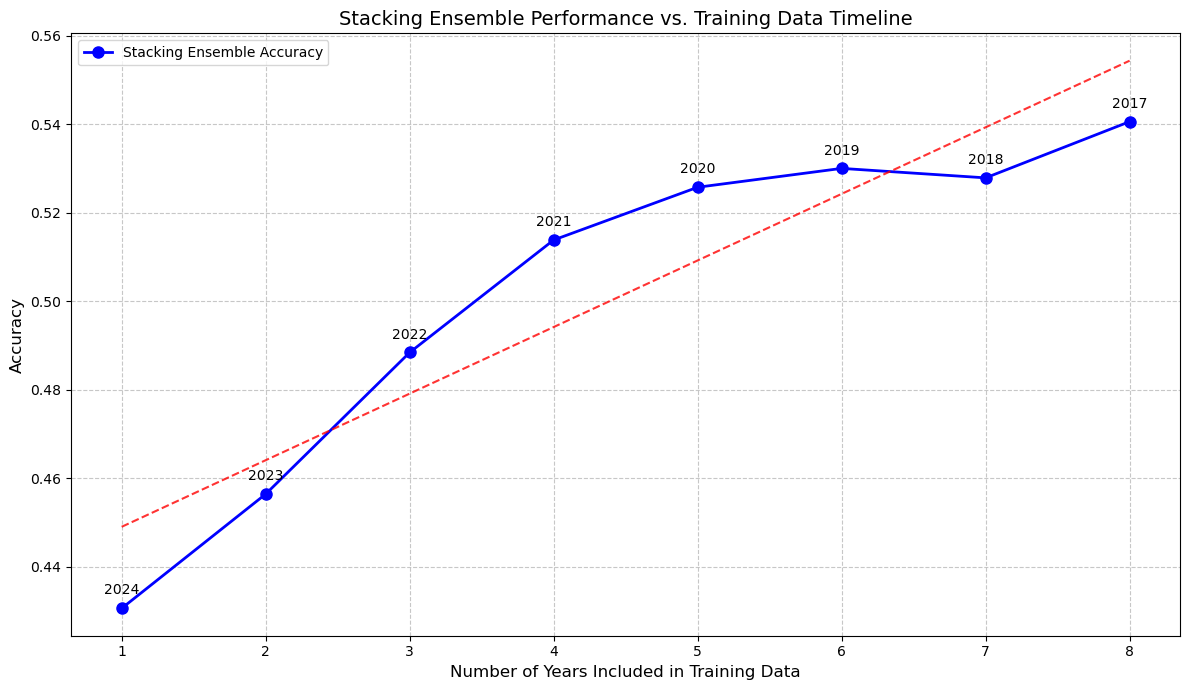

In [ ]:
def train_and_evaluate_ensemble(X, data, years, label_encoder):
    num_years = list(range(1, len(years) + 1))
    accuracies = []

    for year in years:
        # Get cumulative training data
        mask_train = data["year"] >= year

        X_cumulative = X[mask_train]
        y_cumulative = data[mask_train]["FTR"]
        # Split data
        train_size = int(0.8 * len(X_cumulative))
        # Convert DataFrame to numpy array
        X_train_cum = X_cumulative[:train_size]
        X_test_cum = X_cumulative[train_size:]
        y_train_cum = y_cumulative[:train_size].values
        y_test_cum = y_cumulative[train_size:].values
        final_predictions = get_stacking_model_predictions(X_train_cum,y_train_cum,X_test_cum)

        # Calculate accuracy for this year
        accuracy = accuracy_score(y_test_cum, final_predictions)
        accuracies.append(accuracy)

        print(f"Year {year} - Accuracy: {accuracy:.4f}")

    return num_years, accuracies

def plot_yearly_performance(num_years, accuracies, years):
    plt.figure(figsize=(12, 7))

    # Plot accuracy line
    plt.plot(num_years, accuracies, 'bo-', linewidth=2, markersize=8, label="Stacking Ensemble Accuracy")

    # Add year labels
    for i, year in enumerate(years):
        plt.annotate(str(year), (num_years[i], accuracies[i]),
                    textcoords="offset points", xytext=(0,10), ha='center')

    plt.xlabel("Number of Years Included in Training Data", fontsize=12)
    plt.ylabel("Accuracy", fontsize=12)
    plt.title("Stacking Ensemble Performance vs. Training Data Timeline", fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=10)

    # Add trend line
    z = np.polyfit(num_years, accuracies, 1)
    p = np.poly1d(z)
    plt.plot(num_years, p(num_years), "r--", alpha=0.8, label="Trend Line")

    plt.tight_layout()
    plt.show()

# Usage
years = list(range(2024, 2016, -1))
num_years, accuracies = train_and_evaluate_ensemble(X, data, years, label_encoder)
plot_yearly_performance(num_years, accuracies, years)

### 6. Results

Visualization Code

In [ ]:
def plot_confusion_matrix(y_true, y_pred, model_name):
    fig, axes = plt.subplots(1, 1, figsize=(8, 6))
    conf_matrix = confusion_matrix(y_true, y_pred)
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_, ax=axes)
    axes.set_xlabel("Predicted")
    axes.set_ylabel("Actual")
    axes.set_title(f"{model_name} Confusion Matrix Heatmap")

    plt.tight_layout()
    plt.show()

          Classifier  Accuracy  precision  recall  f1-score
0  Linear_Regression     48.84      37.72   48.84     42.38
1                SVM     51.74      48.60   51.74     45.30
2      Random_Forest     54.05      41.04   54.05     46.09
3                XGB     53.28      40.33   53.28     45.88
4        Elastic_Net     52.90      40.09   52.90     44.88
5                MLP     52.90      39.83   52.90     45.21
6                GRU     53.09      40.14   53.09     45.56
7            GRU+MLP     53.09      52.21   53.09     46.26
8  Stacking_Ensemble     54.25      41.00   54.25     46.59


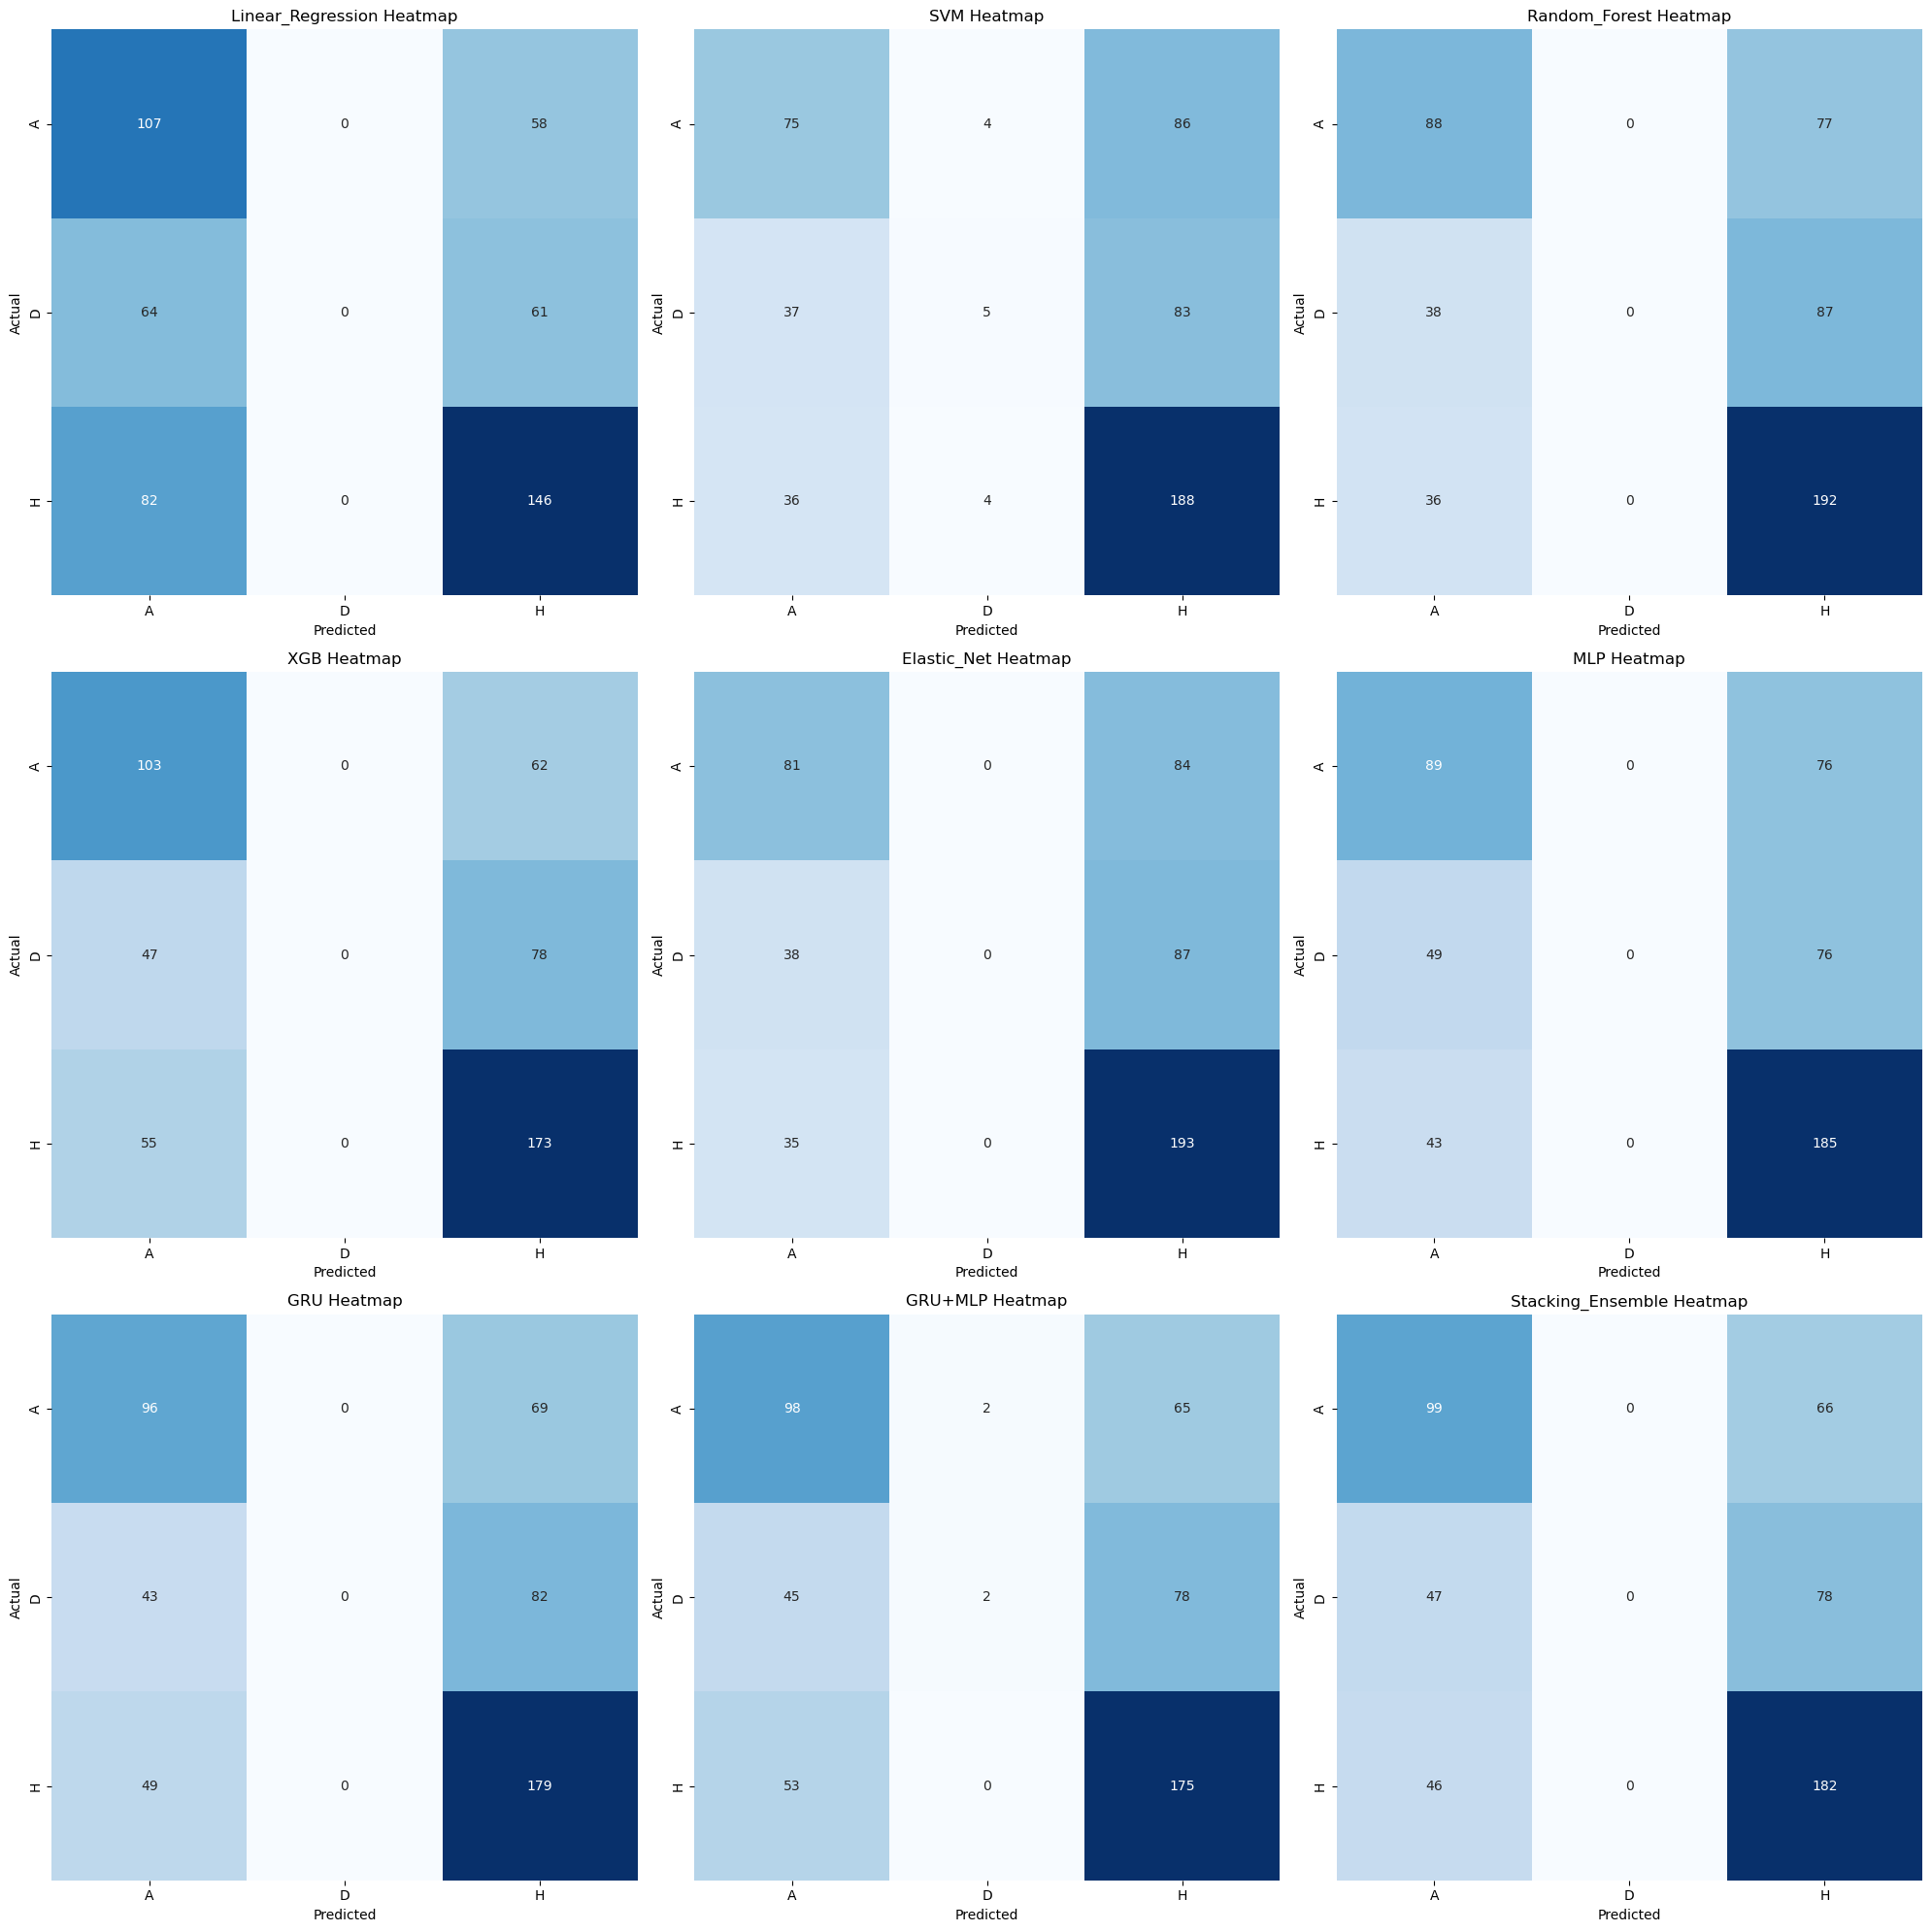

In [113]:
# @title Comparison of all model predictions
all_predictions={
    "Linear_Regression":linear_predictions,
    "SVM":svm_pred,
    "Random_Forest":rf_predictions,
    "XGB":xgb_predictions,
    "Elastic_Net":elastic_net_predictions,
    "MLP":mlp_predictions,
    "GRU":gru_predictions,
    "GRU+MLP":gru_mlp_predictions,
    "Stacking_Ensemble":meta_predictions,

}
fig, axes = plt.subplots(3, 3, figsize=(20, 20))  # 2 rows, 2 columns
reports=[]
for idx,model in enumerate(all_predictions):
    y_pred = all_predictions[model]
    class_report = classification_report(y_test, y_pred,zero_division=0, output_dict=True)
    report = class_report["weighted avg"]
    report["Classifier"] = str(model)
    report["Accuracy"] = accuracy_score(y_test, y_pred)
    reports.append(report)
    conf_matrix = confusion_matrix(y_test, y_pred)
    row = idx // 3
    col = idx % 3
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",cbar=False,
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_, ax=axes[row,col])
    axes[row,col].set_xlabel("Predicted")
    axes[row,col].set_ylabel("Actual")
    axes[row,col].set_title(f"{model} Heatmap")

report = pd.DataFrame(reports)
numerical_cols=["Accuracy", "precision", "recall", "f1-score"]
report[numerical_cols]=report[numerical_cols].apply(lambda x:round(100*x,2),axis=1)
report = report[
            ["Classifier", "Accuracy", "precision", "recall", "f1-score"]
        ].round(4).reset_index(drop=True)
print(report)
plt.tight_layout()
plt.show()

In [ ]:
accuracy = accuracy_score(y_test, linear_predictions)
print(f"Accuracy: {accuracy}")
print(f"F1 Score: {f1_score(y_test, linear_predictions, average='weighted')}")
print("\nClassification Report:")
print(classification_report(y_test, linear_predictions))
linear_conf_matrix = confusion_matrix(y_test, linear_predictions)
print(linear_conf_matrix)

Accuracy: 0.48841698841698844
F1 Score: 0.4237766033965457

Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.65      0.51       165
           1       0.00      0.00      0.00       125
           2       0.55      0.64      0.59       228

    accuracy                           0.49       518
   macro avg       0.32      0.43      0.37       518
weighted avg       0.38      0.49      0.42       518

[[107   0  58]
 [ 64   0  61]
 [ 82   0 146]]


C:\Users\super\anaconda3\envs\COMP0036\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\super\anaconda3\envs\COMP0036\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\super\anaconda3\envs\COMP0036\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)

MLP Results

Accuracy: 0.5290
Confusion Matrix:
 [[ 89   0  76]
 [ 49   0  76]
 [ 43   0 185]]
Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.54      0.51       165
           1       0.00      0.00      0.00       125
           2       0.55      0.81      0.65       228

    accuracy                           0.53       518
   macro avg       0.35      0.45      0.39       518
weighted avg       0.40      0.53      0.45       518

0.4521122153993401


C:\Users\super\anaconda3\envs\COMP0036\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\super\anaconda3\envs\COMP0036\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\super\anaconda3\envs\COMP0036\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)

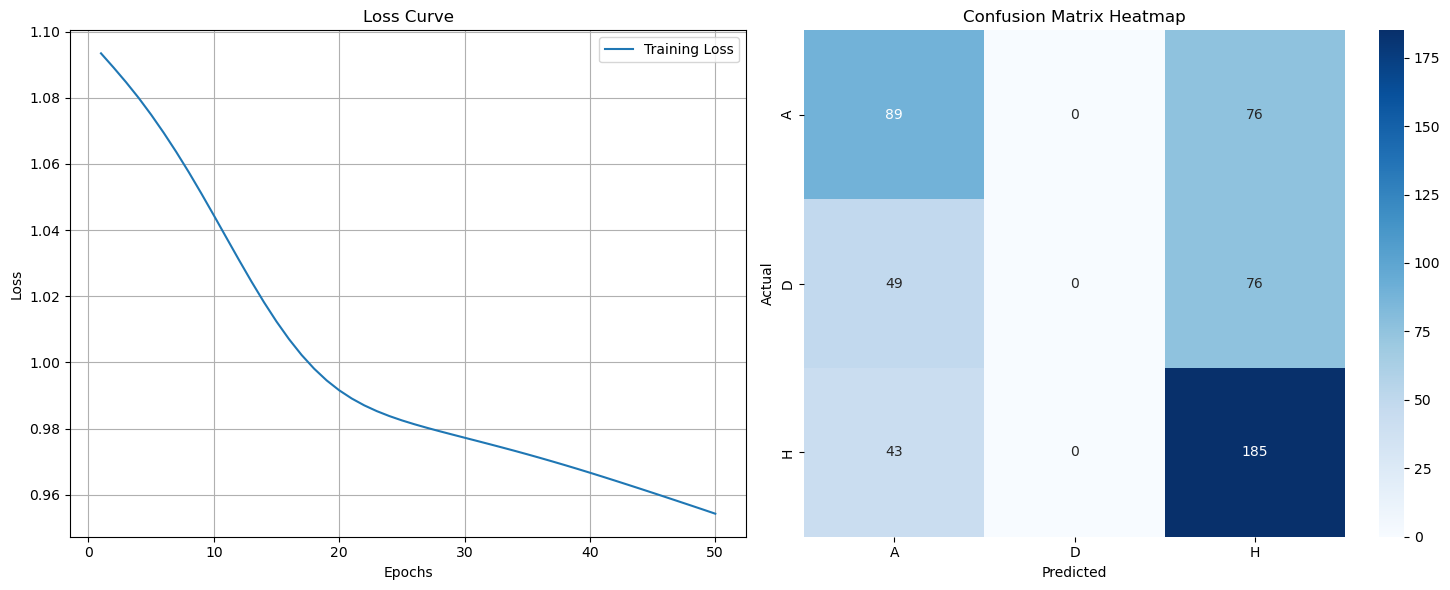

In [ ]:
# @title
print(f"Accuracy: {accuracy_score(y_test,mlp_predictions):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, mlp_predictions))
print("Classification Report:\n", classification_report(y_test, mlp_predictions))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))  # 1 row, 2 columns

# Loss Curve
axes[0].plot(range(1, epochs + 1), loss_history, label="Training Loss")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curve")
axes[0].legend()
axes[0].grid(True)

# Confusion Matrix Heatmap
mlp_cm = confusion_matrix(y_test, mlp_predictions)
sns.heatmap(mlp_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_, ax=axes[1])
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title("Confusion Matrix Heatmap")
print(f1_score(y_test, mlp_predictions, average="weighted"))
plt.tight_layout()
plt.show()

Elastic Net

Accuracy: 0.5290
Confusion Matrix:
 [[ 81   0  84]
 [ 38   0  87]
 [ 35   0 193]]
Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.49      0.51       165
           1       0.00      0.00      0.00       125
           2       0.53      0.85      0.65       228

    accuracy                           0.53       518
   macro avg       0.35      0.45      0.39       518
weighted avg       0.40      0.53      0.45       518



C:\Users\super\anaconda3\envs\COMP0036\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\super\anaconda3\envs\COMP0036\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\super\anaconda3\envs\COMP0036\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)

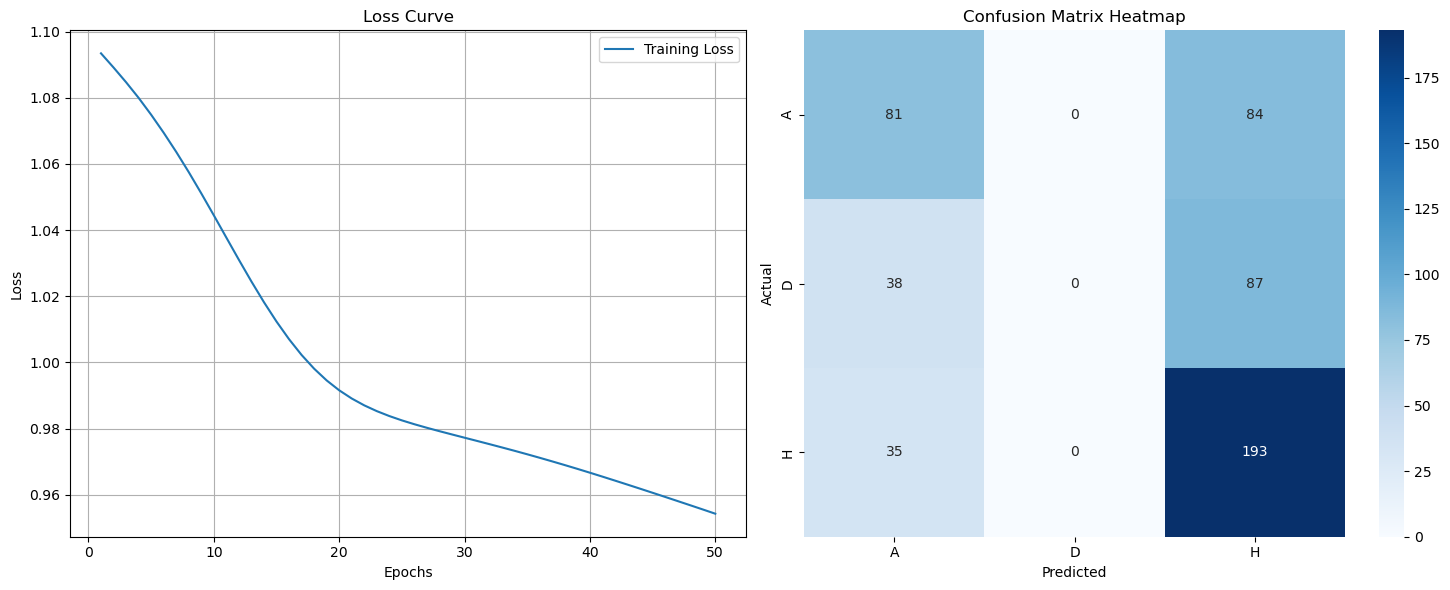

In [ ]:
# @title
print(f"Accuracy: {accuracy_score(y_test,elastic_net_predictions):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, elastic_net_predictions))
print("Classification Report:\n", classification_report(y_test, elastic_net_predictions))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))  # 1 row, 2 columns

# Loss Curve
axes[0].plot(range(1, epochs + 1), loss_history, label="Training Loss")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curve")
axes[0].legend()
axes[0].grid(True)

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, elastic_net_predictions)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_, ax=axes[1])
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title("Confusion Matrix Heatmap")

plt.tight_layout()
plt.show()

SVM Results

Training Accuracy: 0.5497
Training F1 Score: 0.4760

TestingAccuracy: 0.5405405405405406
Testign F1 Score: 0.46714773025452644

 Testing Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.69      0.58       165
           1       0.00      0.00      0.00       125
           2       0.58      0.73      0.64       228

    accuracy                           0.54       518
   macro avg       0.36      0.47      0.41       518
weighted avg       0.41      0.54      0.47       518


SVM Confusion Matrix:


C:\Users\super\anaconda3\envs\COMP0036\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\super\anaconda3\envs\COMP0036\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\super\anaconda3\envs\COMP0036\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)

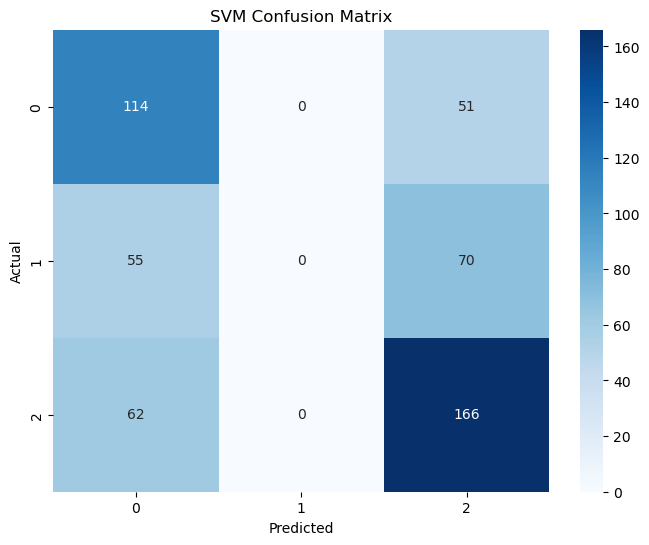

In [ ]:
print(f"Training Accuracy: {svm_train_accuracy:.4f}")
print(f"Training F1 Score: {svm_train_f1:.4f}")
print(f"\nTestingAccuracy: {svm_accuracy}")
print(f"Testign F1 Score: {svm_f1}")
print("\n Testing Classification Report:")
print(classification_report(y_test, svm_pred))
print("\nSVM Confusion Matrix:")
svm_cm = confusion_matrix(y_test, svm_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(svm_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test), ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("SVM Confusion Matrix")
plt.show()

GRU Results

Training Accuracy: 0.5723
Training F1 Score: 0.5053

Validation Accuracy : 0.5239
Validation F1 Score : 0.4656

Test Accuracy: 0.5309
Test F1 Score: 0.4556


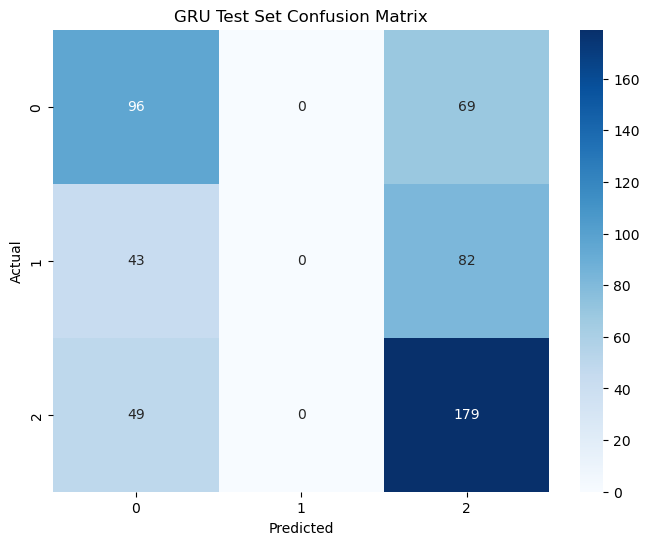

In [ ]:
gru_test_acc = accuracy_score(y_test, gru_predictions)
gru_test_f1  = f1_score(y_test, gru_predictions, average="weighted")
print(f'Training Accuracy: {gru_train_acc:.4f}')
print(f'Training F1 Score: {gru_train_f1:.4f}')
print(f'\nValidation Accuracy : {gru_val_acc:.4f}')
print(f'Validation F1 Score : {gru_val_f1:.4f}')
print(f"\nTest Accuracy: {gru_test_acc:.4f}")
print(f"Test F1 Score: {gru_test_f1:.4f}")

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
conf_matrix = confusion_matrix(y_test, gru_predictions)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test), ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("GRU Test Set Confusion Matrix")
plt.show()

GRU+MLP Results

Training Accuracy: 0.5566
Training F1 Score: 0.4849

Validation Accuracy : 0.5266
Validation F1 Score : 0.4611

Testing Accuracy: 0.5270
Testing F1 Score: 0.4536

GRU+MLP Testing Classification Report
              precision    recall  f1-score   support

           0       0.49      0.61      0.54       165
           1       0.00      0.00      0.00       125
           2       0.55      0.76      0.64       228

    accuracy                           0.53       518
   macro avg       0.35      0.45      0.39       518
weighted avg       0.40      0.53      0.45       518



C:\Users\super\anaconda3\envs\COMP0036\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\super\anaconda3\envs\COMP0036\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\super\anaconda3\envs\COMP0036\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)

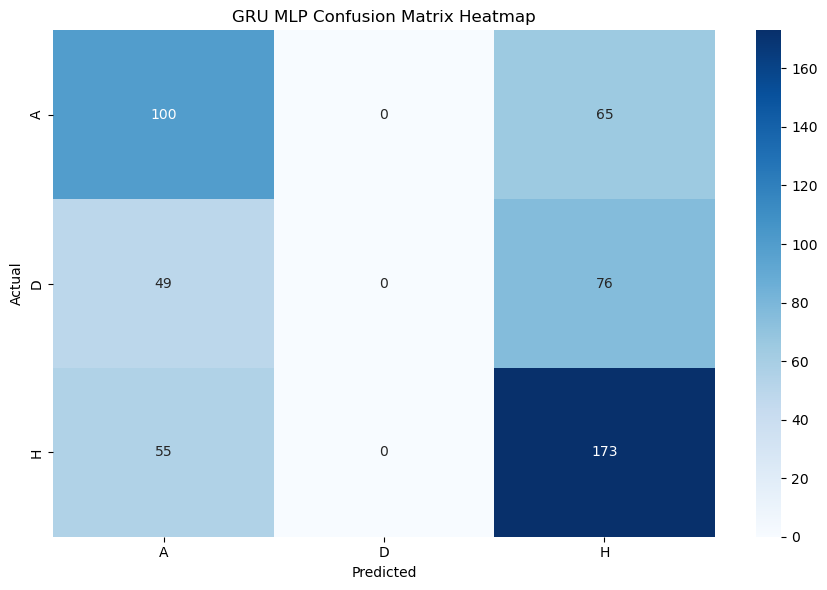

In [ ]:
print(f'Training Accuracy: {gru_mlp_train_acc:.4f}')
print(f'Training F1 Score: {gru_mlp_train_f1:.4f}')
print(f'\nValidation Accuracy : {gru_mlp_val_acc:.4f}')
print(f'Validation F1 Score : {gru_mlp_val_f1:.4f}')
print(f'\nTesting Accuracy: {accuracy_score(y_test, gru_mlp_predictions):.4f}')
print(f'Testing F1 Score: {f1_score(y_test, gru_mlp_predictions, average="weighted"):.4f}')

print("\nGRU+MLP Testing Classification Report")
print(classification_report(y_test, gru_mlp_predictions))

fig, axes = plt.subplots(1, 1, figsize=(9, 6))
gru_mlp_conf_matrix = confusion_matrix(y_test, gru_mlp_predictions)

sns.heatmap(gru_mlp_conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_, ax=axes)
axes.set_xlabel("Predicted")
axes.set_ylabel("Actual")
axes.set_title("GRU MLP Confusion Matrix Heatmap")

plt.tight_layout()
plt.show()

Random Forest Results

Accuracy: 0.540541
F1 Score: 0.46085935843382114
RandomForest Classification Report
              precision    recall  f1-score   support

           0       0.54      0.53      0.54       165
           1       0.00      0.00      0.00       125
           2       0.54      0.84      0.66       228

    accuracy                           0.54       518
   macro avg       0.36      0.46      0.40       518
weighted avg       0.41      0.54      0.46       518



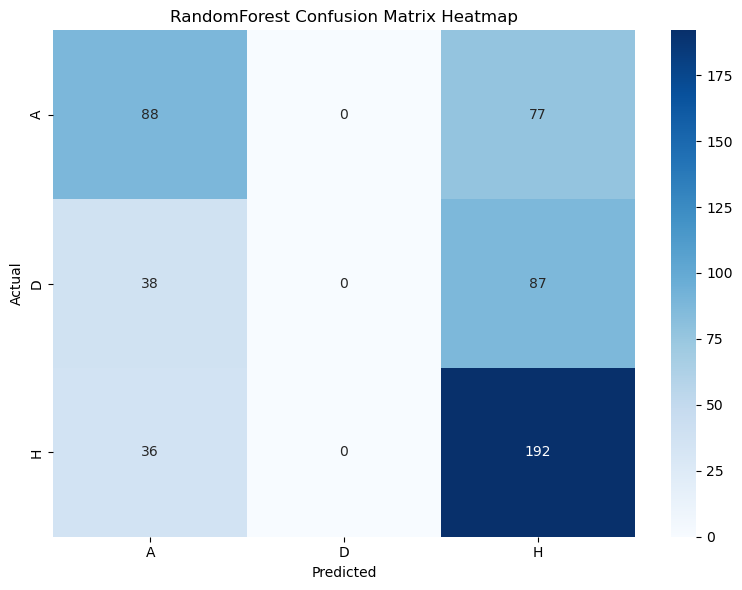

In [ ]:
print(f'Accuracy: {accuracy_score(y_test, rf_predictions):.6f}')
print(f'F1 Score: {f1_score(y_test, rf_predictions, average="weighted")}')
print("RandomForest Classification Report")
print(classification_report(y_test, rf_predictions,zero_division=0))
plot_confusion_matrix(y_test,rf_predictions,"RandomForest")

XGB Results

Accuracy: 0.532819
F1 Score: 0.4588488780675422
RandomForest Classification Report
              precision    recall  f1-score   support

           0       0.50      0.62      0.56       165
           1       0.00      0.00      0.00       125
           2       0.55      0.76      0.64       228

    accuracy                           0.53       518
   macro avg       0.35      0.46      0.40       518
weighted avg       0.40      0.53      0.46       518



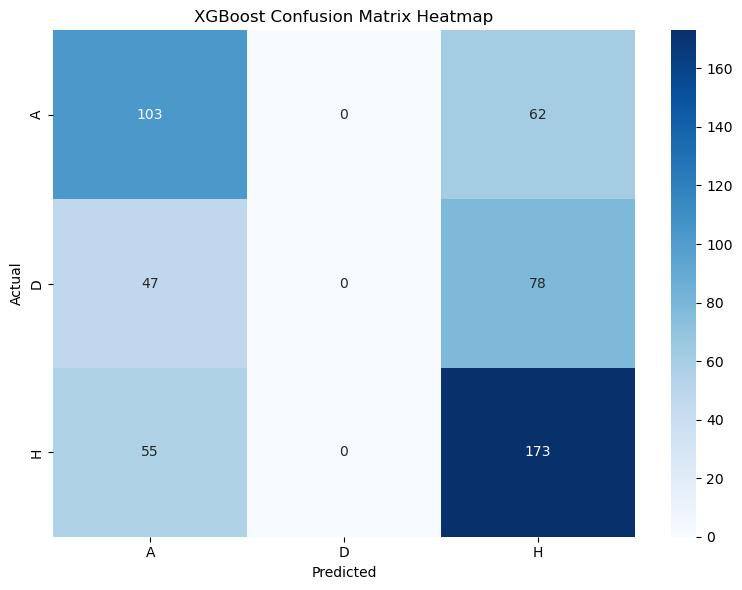

In [ ]:
print(f'Accuracy: {accuracy_score(y_test, xgb_predictions):.6f}')
print(f'F1 Score: {f1_score(y_test, xgb_predictions, average="weighted")}')
print("RandomForest Classification Report")
print(classification_report(y_test, xgb_predictions,zero_division=0))
plot_confusion_matrix(y_test,xgb_predictions,"XGBoost")

#### Meta Model Results



Stacking Accuracy: 0.5405405405405406

Stacking F1 Score: 0.4640041252340799

Stacking Classification Report:
  Classifier  Accuracy  precision  recall  f1-score
0    Stacked     54.05      40.87   54.05      46.4
              precision    recall  f1-score   support

           A       0.52      0.59      0.55       165
           D       0.00      0.00      0.00       125
           H       0.55      0.80      0.65       228

    accuracy                           0.54       518
   macro avg       0.36      0.46      0.40       518
weighted avg       0.41      0.54      0.46       518


Stacking Confusion Matrix:


C:\Users\super\anaconda3\envs\COMP0036\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\super\anaconda3\envs\COMP0036\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\super\anaconda3\envs\COMP0036\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)

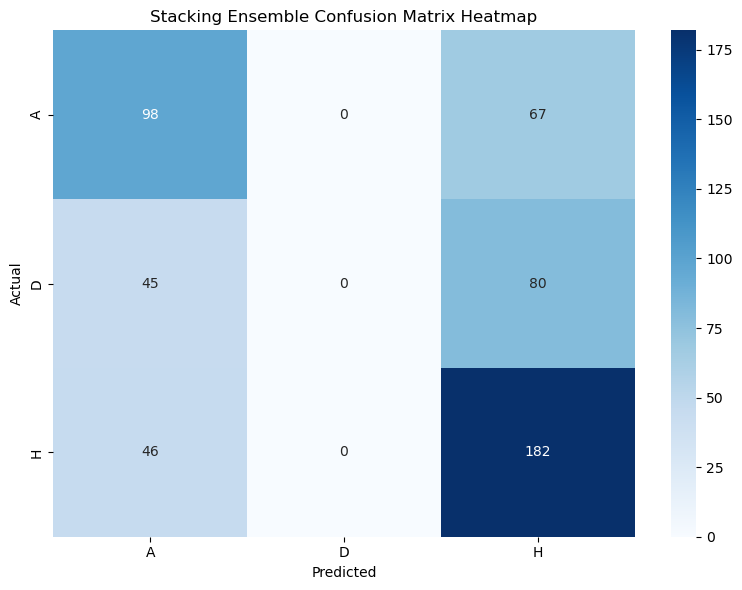

In [ ]:
stacking_accuracy = accuracy_score(y_test, meta_predictions)
stacking_f1 = f1_score(y_test, meta_predictions, average="weighted")

print(f"\nStacking Accuracy: {stacking_accuracy}")
print(f"\nStacking F1 Score: {stacking_f1}")
print("\nStacking Classification Report:")

class_report = classification_report(y_test, meta_predictions, output_dict=True)["weighted avg"]
class_report["Classifier"] = "Stacked"
class_report["Accuracy"] = accuracy_score(y_test, meta_predictions)
report = pd.DataFrame([class_report])
numerical_cols=["Accuracy", "precision", "recall", "f1-score"]
report[numerical_cols]=report[numerical_cols].apply(lambda x:round(100*x,2),axis=1)
print(
        report[
            ["Classifier", "Accuracy", "precision", "recall", "f1-score"]
        ].round(4).sort_values(by="f1-score", ascending=False).reset_index(drop=True)
    )
print(classification_report(y_test, meta_predictions,target_names=label_encoder.classes_))

print("\nStacking Confusion Matrix:")
plot_confusion_matrix(y_test,meta_predictions,"Stacking Ensemble")


Linear Regression Results

Accuracy: 0.488417
F1 Score: 0.4237766033965457
Linear Regression Classification Report
              precision    recall  f1-score   support

           0       0.42      0.65      0.51       165
           1       0.00      0.00      0.00       125
           2       0.55      0.64      0.59       228

    accuracy                           0.49       518
   macro avg       0.32      0.43      0.37       518
weighted avg       0.38      0.49      0.42       518



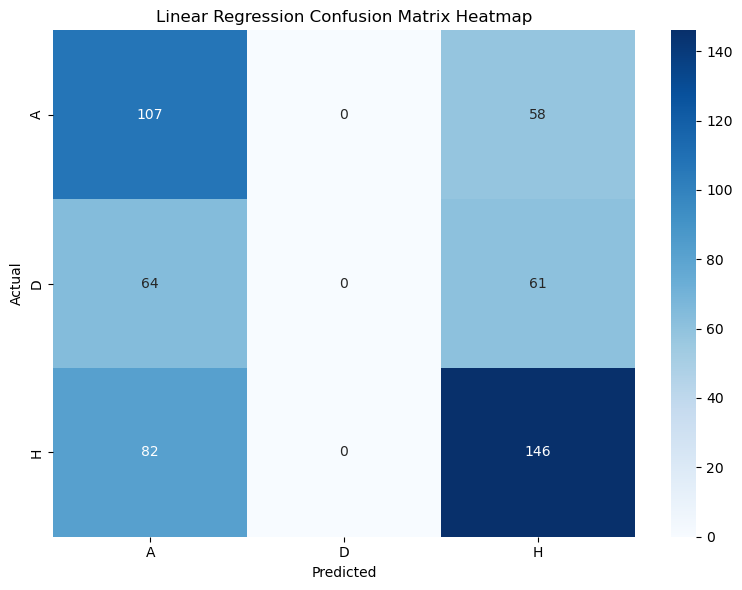

In [ ]:
print(f'Accuracy: {accuracy_score(y_test, linear_predictions):.6f}')
print(f'F1 Score: {f1_score(y_test, linear_predictions, average="weighted")}')
print("Linear Regression Classification Report")
print(classification_report(y_test, linear_predictions,zero_division=0))
plot_confusion_matrix(y_test,linear_predictions,"Linear Regression")

### 7. Final Predictions on Test Set

The test data is first restructured so that it is in the same format as our raw dataset. Particularly, the test set uses aliases for some of the team names, requiring them to be remapped to match the names in our dataset. The test and raw data are then concatenated and preprocessed.

In [ ]:
# @title
def restructure_test_data(df):
    new_data = []
    team_name_remapping = {
        "AFC Bournemouth": "Bournemouth",
        "Man City": "Manchester City",
        "Nottingham Forest": "Nott'ham Forest",
        "Newcastle": "Newcastle Utd",
        "Spurs": "Tottenham",
        "Man Utd": "Manchester Utd",
    }
    for _, row in df.iterrows():
        new_data.append(
            {
                "Date": pd.to_datetime(row["Date"]),
                "Team": team_name_remapping.get(row["HomeTeam"], row["HomeTeam"]),
                "Opp": team_name_remapping.get(row["AwayTeam"], row["AwayTeam"]),
                "Unnamed: 13": "",
            }
        )
        new_data.append(
            {
                "Date": pd.to_datetime(row["Date"]),
                "Team": team_name_remapping.get(row["AwayTeam"], row["AwayTeam"]),
                "Opp": team_name_remapping.get(row["HomeTeam"], row["HomeTeam"]),
                "Unnamed: 13": "@",
            }
        )
    return pd.DataFrame(new_data)

def get_combined_data(test_data_path):
    raw_data = get_all_season_data(data_dir)
    test_data = pd.read_csv(test_data_path)
    test_data = restructure_test_data(test_data)
    # Align smaller_df to match larger_df's columns
    test_data = test_data.reindex(columns=raw_data.columns)
    test_data = test_data.fillna(0)
    # Append the smaller DataFrame to the larger one
    df_final = pd.concat([raw_data, test_data], ignore_index=True)

    df_features_final = transform_raw_data(df_final)
    return df_features_final


def prepare_data(data: pd.DataFrame):
    data["FTR"] = data["FTR"].astype("category")
    label_encoder = LabelEncoder()
    label_encoder.fit(data["FTR"])
    data["FTR"] = label_encoder.transform(data["FTR"])
    y = data["FTR"]
    # Prepare the data
    object_columns = [
        "f_HM1",
        "f_HM2",
        "f_HM3",
        "f_HM4",
        "f_HM5",
        "f_AM1",
        "f_AM2",
        "f_AM3",
        "f_AM4",
        "f_AM5",
        "f_HTFormPtsStr",
        "f_ATFormPtsStr",
    ]
    data = data.drop(columns = object_columns)
    data = data.drop(columns = features_to_remove)
    X = data[[col for col in data.columns if col.startswith("f_")]]
    imputer = SimpleImputer(strategy="mean")
    X = imputer.fit_transform(X)
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    return X, y, label_encoder

Finally, we train the stacking ensemble model on the whole dataset (apart from the test set) and obtain the prediction for the matches in the test set.
**Change test_data_path to the path of sample-submission.csv in the submission.zip**


In [ ]:
# @title
def get_predictions(test_data_path):
    df_features_final = get_combined_data(test_data_path)

    X, y, encoder = prepare_data(df_features_final)
    # Select our test data
    mask = df_features_final["Date"] >= "2025-02-01"

    X_train = X[~mask]
    y_train = y[~mask]
    X_test = X[mask]
    print(X_train.shape,y_train.shape)
    print(X_test.shape)
    predictions = get_stacking_model_predictions(X_train,y_train,X_test)
    y_pred = encoder.inverse_transform(predictions)

    df_prediction = df_features_final[mask]
    df_prediction["FTR"] = y_pred
    df_prediction = df_prediction[
        ["Date", "HomeTeam", "AwayTeam", "FTR"]
    ].reset_index(drop=True)

    return df_prediction

# Change this to the correct path
test_data_path = "submission/sample-submission.csv"
final_prediction = get_predictions(test_data_path)

Original Length: 5716 132
After dropping NaN: 5716 132
After dropping duplicate rows: 5716 132
After dropping duplicate columns: 5716 111
After dropping columns: 5716 108
Data cleaned shape: (5502, 108)
Data added performance indicators shape: (5502, 115)
Data ema features shape: (5440, 225)
Data restructured shape: (2600, 444)
Data shape after adding seasonal features: (2600, 477)
Data shape after adding team elo: (2600, 487)
Data shape after adding pi rating: (2600, 495)
(2590, 160) (2590,)
(10, 160)
Epoch 2/10, Loss: 1.1006, Acc: 0.3333
Epoch 4/10, Loss: 1.0975, Acc: 0.3167
Epoch 6/10, Loss: 1.0924, Acc: 0.3708
Epoch 8/10, Loss: 1.0851, Acc: 0.4750
Epoch 10/10, Loss: 1.0771, Acc: 0.5333
Epoch 2/10, Loss: 1.1010, Acc: 0.3053
Epoch 4/10, Loss: 1.0873, Acc: 0.4758
Epoch 6/10, Loss: 1.0764, Acc: 0.5263
Epoch 8/10, Loss: 1.0598, Acc: 0.5179
Epoch 10/10, Loss: 1.0380, Acc: 0.5326
Epoch 2/10, Loss: 1.0964, Acc: 0.3352
Epoch 4/10, Loss: 1.0820, Acc: 0.4535
Epoch 6/10, Loss: 1.0570, Acc: 0.5

C:\Users\super\AppData\Local\Temp\ipykernel_15592\3448219122.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_prediction["FTR"] = y_pred


View the predictions and save them to a file:

In [ ]:
final_prediction.to_csv("submission/final_predictions.csv",index=False)
final_prediction

,Date,HomeTeam,AwayTeam,FTR
0,2025-02-01,Arsenal,Manchester City,H
1,2025-02-01,Brentford,Tottenham,H
2,2025-02-01,Bournemouth,Liverpool,A
3,2025-02-01,Nott'ham Forest,Brighton,H
4,2025-02-01,Chelsea,West Ham,H
5,2025-02-01,Newcastle Utd,Fulham,H
6,2025-02-01,Ipswich Town,Southampton,H
7,2025-02-01,Manchester Utd,Crystal Palace,H
8,2025-02-01,Everton,Leicester City,H
9,2025-02-01,Wolves,Aston Villa,A
